# Patient 5

In this jupyter notebook the data of patient 2 is loaded, inspected and processed. 
There are some special remarks on this dataset. See dataset_notes_all.md

In [1]:
# imports
import pickle
#import os
#import re 
import mne
import numpy as np
import matplotlib.pyplot as plt
#from pathlib import Path
#from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
#import sklearn.metrics as metrics
#import scipy as sp
#import scipy.stats as stats
import warnings
#from sklearn.pipeline import make_pipeline
#from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from toeplitzlda.classification import ToeplitzLDA
#import logging
#import math

# utils functions
from utils.preprocessing import all_have_same_condition, inspect_session, get_n_epochs, get_iteration_structure, get_n_iterations, load_session_chached, merge_sessions, _have_same_preprocessing
from utils.marker_functions import get_markers_of_session, get_markers_of_patient, get_session_filenames_with_markers, all_runs_contain_marker, log_patient_marker_information
from utils.offline_evaluation import compare_auc_single_trial_interval, compute_auc_with_cv
from utils.online_simulation import online_simulation, online_adaptation_simulation_sw

# Turn off warnings (that most likely occur from ToeplitzLDA)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
mne.set_log_level('WARNING')



In [3]:
load_session_chached(f"B:/anonymized_data/P09a/P9_S15/anonymized")

Loading file:  B:_anonymized_data_P09a_P9_S15_anonymized
Corresponding .pkl file:  B:_anonymized_data_P09a_P9_S15_anonymized.pkl
A .pkl file does not exist yet. Loading the data and creating B:_anonymized_data_P09a_P9_S15_anonymized.pkl... (this might take a few mins)
All conditions of this session are the same:  False
Number of iterations per trial:


FileNotFoundError: [Errno 2] No such file or directory: 'B:\\anonymized_data\\P09a\\P9_S15\\anonymized\\auditoryAphasia_HP_650_Block1_Run1.vmrk'

In [6]:
filenames_p2 = list()
for s in range(1,2): 
    #print(f"--------------------------------- Session {s} ---------------------------------")
    data_path = f"B:/anonymized_data/P09a/P9_S15/anonymized"
    #data_path = f"data_p1/P1_S{s}/anonymized"
    filenames = get_session_filenames_with_markers(data_path, track_progress=True)
    for f in filenames:
        if len(filenames.get(f))>0:
            print(f"{f}: {filenames.get(f)}")

    filenames_p2 += (filenames)

Loaded P9_S15/anonymized/auditoryAphasia_01HP_650_Block1_Run1.vhdr
Loaded P9_S15/anonymized/auditoryAphasia_02HP_650_Block1_Run2.vhdr
Loaded P9_S15/anonymized/auditoryAphasia_03HP_650_Block1_Run3.vhdr
Loaded P9_S15/anonymized/auditoryAphasia_04HP_650_Block1_Run4.vhdr
Loaded P9_S15/anonymized/auditoryAphasia_05HP_650_Block1_Run5.vhdr
Loaded P9_S15/anonymized/auditoryAphasia_06HP_650_Block1_Run6.vhdr
Loaded P9_S15/anonymized/auditoryAphasia_HP_1000_Block2_Run1.vhdr
Loaded P9_S15/anonymized/auditoryAphasia_HP_1000_Block2_Run2.vhdr
Loaded P9_S15/anonymized/auditoryAphasia_HP_1000_Block2_Run3.vhdr
Loaded P9_S15/anonymized/auditoryAphasia_HP_1000_Block2_Run4.vhdr
Loaded P9_S15/anonymized/auditoryAphasia_HP_1000_Block2_Run5.vhdr
Loaded P9_S15/anonymized/auditoryAphasia_HP_1000_Block2_Run6.vhdr
Loaded P9_S15/anonymized/auditoryAphasia_HP_1000_Block3_Run1.vhdr
P9_S15/anonymized/auditoryAphasia_01HP_650_Block1_Run1.vhdr: [(101, 35), (102, 35), (103, 35), (104, 35), (105, 35), (106, 35), (111, 7)

In [ ]:
# old
filenames_p2 = list()
for s in range(1,15): 
    #print(f"--------------------------------- Session {s} ---------------------------------")
    data_path = f"B:/anonymized_data/P09a/P9_S15/anonymized"
    #data_path = f"data_p1/P1_S{s}/anonymized"
    filenames = get_session_filenames_with_markers(data_path, track_progress=True)
    for f in filenames:
        if len(filenames.get(f))>0:
            print(f"{f}: {filenames.get(f)}")

    filenames_p2 += (filenames)

for filename in filenames_p2:
    print(filename)

Loaded P9_S15/anonymized/auditoryAphasia_HP_1000_Block2_Run1.vhdr
Loaded P9_S15/anonymized/auditoryAphasia_HP_1000_Block2_Run2.vhdr
Loaded P9_S15/anonymized/auditoryAphasia_HP_1000_Block2_Run3.vhdr
Loaded P9_S15/anonymized/auditoryAphasia_HP_1000_Block2_Run4.vhdr
Loaded P9_S15/anonymized/auditoryAphasia_HP_1000_Block2_Run5.vhdr
Loaded P9_S15/anonymized/auditoryAphasia_HP_1000_Block2_Run6.vhdr
Loaded P9_S15/anonymized/auditoryAphasia_HP_1000_Block3_Run1.vhdr
Loaded P9_S15/anonymized/auditoryAphasia_HP_650_Block1_Run1.vhdr
Loaded P9_S15/anonymized/auditoryAphasia_HP_650_Block1_Run2.vhdr
Loaded P9_S15/anonymized/auditoryAphasia_HP_650_Block1_Run3.vhdr
Loaded P9_S15/anonymized/auditoryAphasia_HP_650_Block1_Run4.vhdr
Loaded P9_S15/anonymized/auditoryAphasia_HP_650_Block1_Run5.vhdr
Loaded P9_S15/anonymized/auditoryAphasia_HP_650_Block1_Run6.vhdr
P9_S15/anonymized/auditoryAphasia_HP_1000_Block2_Run1.vhdr: [(101, 35), (102, 35), (103, 35), (104, 35), (105, 35), (106, 35), (111, 7), (112, 7), (

In [25]:
import line_profiler
%load_ext line_profiler

# Example:
# %lprun -f my_function my_function(500000)

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


## Real online simulation

Procedure
1. Load data
2. Train a classifier on calibration data and evaluate the offline performance
3. Test static classifier in an online simulation of session 3
4. Test adaptive sliding window 

In [22]:
with open("p2_performances_first.pkl", 'wb') as f: # this is wrong! I tested all data on patient 1 data...
    pickle.dump(p2_performances_first, f)


In [21]:
p2_performances_first = dict()
p2_performances_first.update(p2_performances_s3)
p2_performances_first.update(p2_performances_s4_to_s13)
print(p2_performances_first.keys())

dict_keys(['p2_s3_static', 'p2_s3_adaptive_sw', 'p2_s4_static', 'p2_s4_adaptive_sw', 'p2_s5_static', 'p2_s5_adaptive_sw', 'p2_s6_static', 'p2_s6_adaptive_sw', 'p2_s7_static', 'p2_s7_adaptive_sw', 'p2_s8_static', 'p2_s8_adaptive_sw', 'p2_s9_static', 'p2_s9_adaptive_sw', 'p2_s10_static', 'p2_s10_adaptive_sw', 'p2_s11_static', 'p2_s11_adaptive_sw', 'p2_s12_static', 'p2_s12_adaptive_sw', 'p2_s13_static', 'p2_s13_adaptive_sw'])


### Session 3

In [13]:
print(p2_performances_s3.keys())
print(p2_performances_s3.get('p2_s3_static'))

dict_keys(['p2_s3_static', 'p2_s3_adaptive_sw'])
{'epoch-wise': {'lda': 0.5938658625115731, 'slda': 0.5878070159287939, 'btlda': 0.5885251399292989}, 'trial-wise': {'lda': 0.5166666666666667, 'slda': 0.4583333333333333, 'btlda': 0.43333333333333335}, 'trial_predictions': {'lda': array([2., 4., 3., 5., 2., 1., 1., 4., 4., 5., 6., 2., 6., 6., 6., 4., 6.,
       4., 5., 5., 5., 4., 2., 2., 2., 6., 6., 3., 5., 4., 4., 3., 4., 2.,
       2., 6., 5., 4., 2., 1., 6., 3., 4., 5., 2., 1., 2., 2., 1., 1., 5.,
       4., 6., 3., 5., 1., 3., 2., 1., 5., 5., 3., 1., 6., 2., 2., 1., 6.,
       6., 4., 5., 4., 6., 1., 2., 3., 1., 1., 4., 2., 6., 3., 1., 6., 1.,
       4., 4., 2., 5., 1., 3., 5., 1., 3., 4., 5., 2., 6., 3., 1., 3., 5.,
       4., 2., 5., 5., 2., 4., 1., 4., 6., 2., 1., 2., 6., 5., 3., 2., 3.,
       1.]), 'slda': array([4., 2., 3., 4., 2., 1., 6., 5., 4., 4., 6., 5., 6., 6., 6., 4., 5.,
       1., 5., 6., 5., 4., 2., 2., 2., 6., 6., 3., 2., 4., 4., 3., 4., 2.,
       4., 1., 5., 4., 2

Loading file:  B:_anonymized_data_P02a_P2_S1_anonymized
Corresponding .pkl file:  B:_anonymized_data_P02a_P2_S1_anonymized6D_long_350_dc.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P02a_P2_S1_anonymized6D_long_350_dc.pkl
Loading file:  B:_anonymized_data_P02a_P2_S2_anonymized
Corresponding .pkl file:  B:_anonymized_data_P02a_P2_S2_anonymized6D_long_350_dc.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P02a_P2_S2_anonymized6D_long_350_dc.pkl
All calibration trials:  48
That is 4320 epochs

Loading file:  B:_anonymized_data_P02a_P2_S3_anonymized
Corresponding .pkl file:  B:_anonymized_data_P02a_P2_S3_anonymized.pkl
A .pkl file does not exist yet. Loading the data and creating B:_anonymized_data_P02a_P2_S3_anonymized.pkl... (this might take a few mins)
All conditions of this session are the same:  True
Number of iterations per trial:
Run 1: [15. 15. 15. 15. 15. 15.]
Run 2: [15. 15. 15. 15. 15. 15.]
Run 3: [15. 15. 15. 15. 15. 15.]
Run

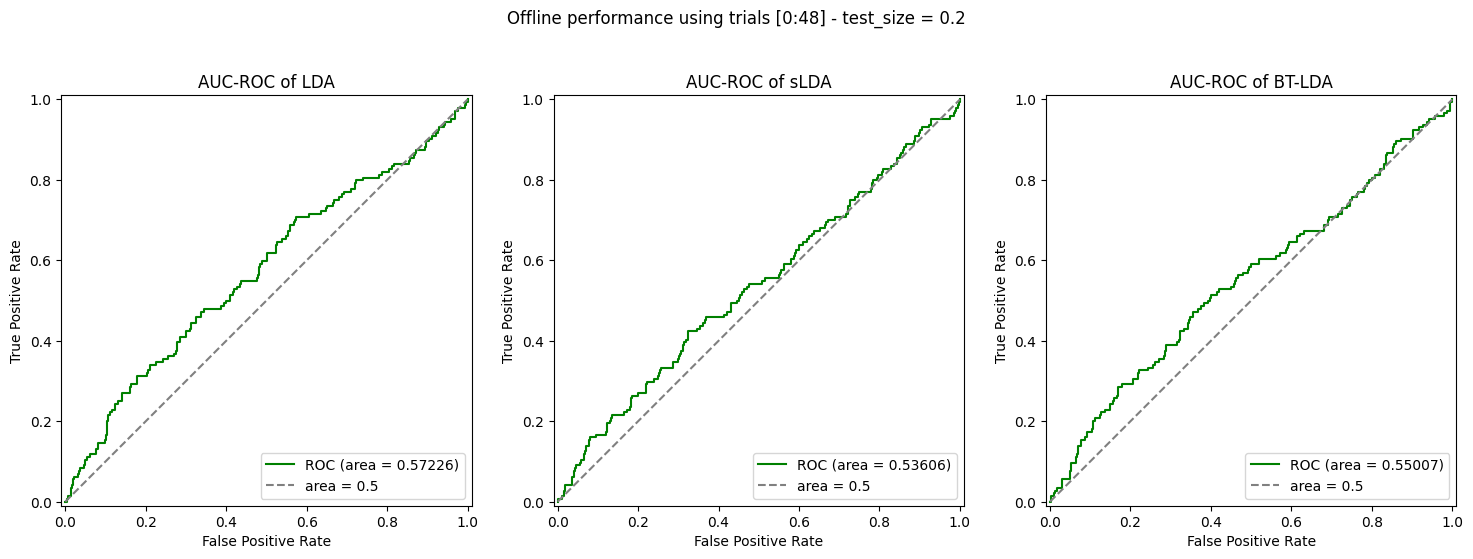

AUC scores computed using a 4-fold cross-validation
Mean AUC score of LDA: 		 0.5973333333333334
Mean AUC score of sLDA: 	 0.5841728395061729
Mean AUC score of BT-LDA: 	 0.5944583333333333
trial 0/120
trial 1/120
trial 2/120
trial 3/120
trial 4/120
trial 5/120
trial 6/120
trial 7/120
trial 8/120
trial 9/120
trial 10/120
trial 11/120
trial 12/120
trial 13/120
trial 14/120
trial 15/120
trial 16/120
trial 17/120
trial 18/120
trial 19/120
trial 20/120
trial 21/120
trial 22/120
trial 23/120
trial 24/120
trial 25/120
trial 26/120
trial 27/120
trial 28/120
trial 29/120
trial 30/120
trial 31/120
trial 32/120
trial 33/120
trial 34/120
trial 35/120
trial 36/120
trial 37/120
trial 38/120
trial 39/120
trial 40/120
trial 41/120
trial 42/120
trial 43/120
trial 44/120
trial 45/120
trial 46/120
trial 47/120
trial 48/120
trial 49/120
trial 50/120
trial 51/120
trial 52/120
trial 53/120
trial 54/120
trial 55/120
trial 56/120
trial 57/120
trial 58/120
trial 59/120
trial 60/120
trial 61/120
trial 62/120
tr

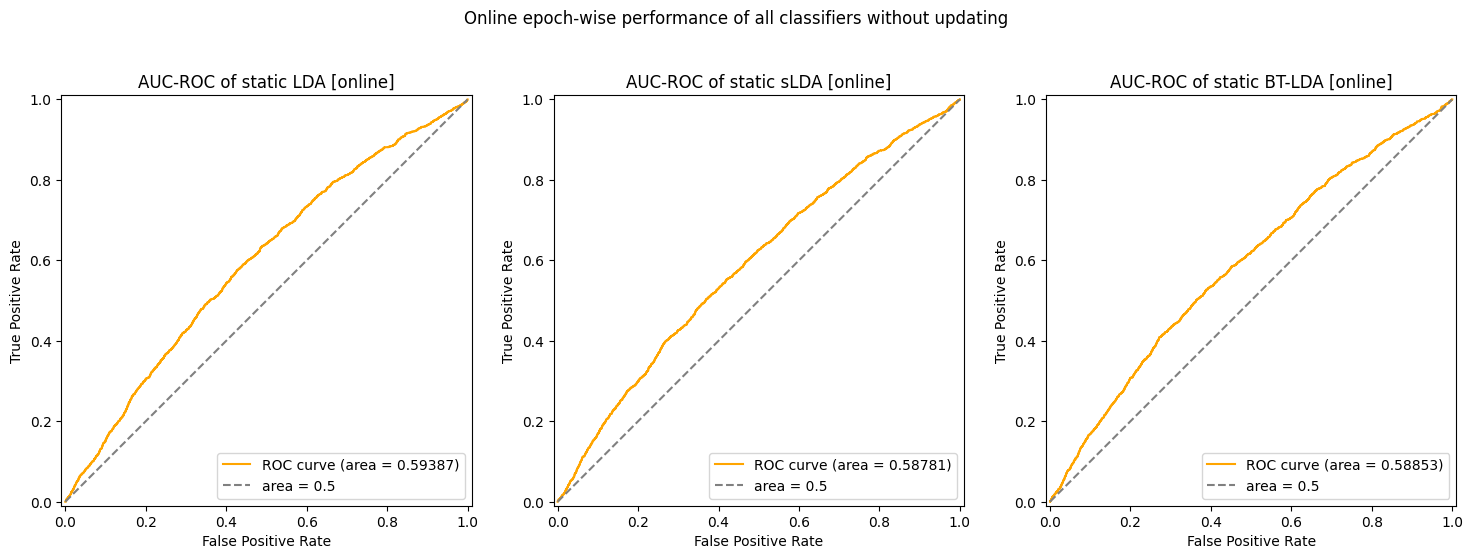

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.51667
Accuracy SLDA: 0.45833
Accuracy BT-LDA: 0.43333
trial 0/120
trial 1/120
trial 2/120
trial 3/120
trial 4/120
trial 5/120
trial 6/120
trial 7/120
trial 8/120
trial 9/120
trial 10/120
trial 11/120
trial 12/120
trial 13/120
trial 14/120
trial 15/120
trial 16/120
trial 17/120
trial 18/120
trial 19/120
trial 20/120
trial 21/120
trial 22/120
trial 23/120
trial 24/120
trial 25/120
trial 26/120
trial 27/120
trial 28/120
trial 29/120
trial 30/120
trial 31/120
trial 32/120
trial 33/120
trial 34/120
trial 35/120
trial 36/120
trial 37/120
trial 38/120
trial 39/120
trial 40/120
trial 41/120
trial 42/120
trial 43/120
trial 44/120
trial 45/120
trial 46/120
trial 47/120
trial 48/120
trial 49/120
trial 50/120
trial 51/120
trial 52/120
trial 53/120
trial 54/120
trial 55/120
trial 56/120
trial 57/120
trial 58/120
trial 59/120
trial 60/120
trial 61/120
trial 62/120
trial 63/120
trial 64/120
trial 65/120
tria

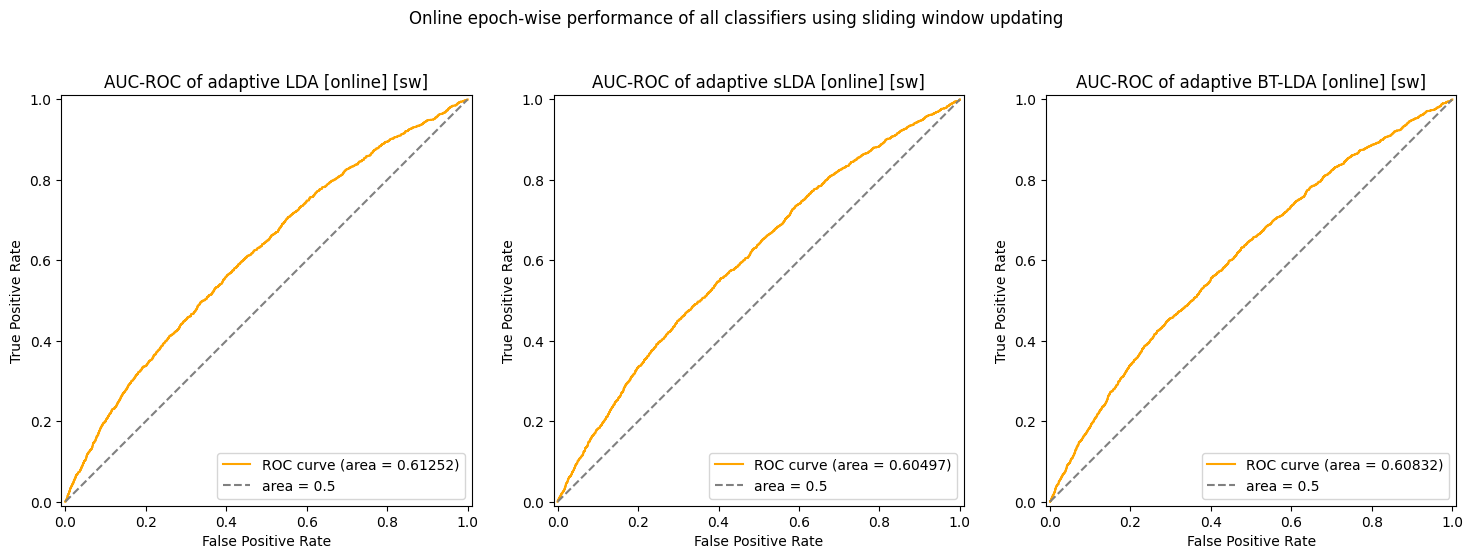

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.59167
Accuracy SLDA: 0.52500
Accuracy BT-LDA: 0.50833


In [10]:
p2_performances_s3 = dict()


### Session 3 --------------------------------------------------------
# Calibration data: sessions 1 and 2 (only runs with conditions 6D and 350)
data_path_s1 = "B:/anonymized_data/P02a/P2_S1/anonymized"
data_path_s2 = "B:/anonymized_data/P02a/P2_S2/anonymized"
data_s1 = load_session_chached(data_path_s1, selection = "6D_long_350",discard_channels=True)
data_s2 = load_session_chached(data_path_s2, selection = "6D_long_350",discard_channels=True)
data_train = merge_sessions(data_s1, data_s2)
trials_train = data_train.get('trials')
print("All calibration trials: ",len(trials_train))
print("That is {} epochs\n".format(get_n_epochs(trials_train)))
ppcal = data_train.get('preprocessing')
fncal = data_train.get('filenames')
data_test = load_session_chached(f"B:/anonymized_data/P02a/P2_S3/anonymized")
trials_test = data_test.get("trials")
ppon = data_test.get('preprocessing')
fnon = data_test.get('filenames')

# 2. Evaluate offline performance 
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
compare_auc_single_trial_interval(trials_train, start=0, stop=None, test_size=0.2, only_auc = True, ival_bounds = clf_ival_boundaries, plot_roc_curves=True)
compute_auc_with_cv(trials_train, start=0, stop=None, ival_bounds=clf_ival_boundaries, cv_folds=4, show_mean=True, show_folds=False)

# 3. Online simulation static
static_result = online_simulation(trials_train, trials_test, log_process=f"p2_s3_online_static.log", preprocessing_calibration=ppcal, preprocessing_online=ppon, filenames_calibration=fncal, filenames_online=fnon)

# 4. Online simulation adaptation (sw)
adaptive_sw_result = online_adaptation_simulation_sw(trials_train, trials_test, log_process=f"p2_s3_online_adaptive_sw.log", preprocessing_calibration=ppcal, preprocessing_online=ppon, filenames_calibration=fncal, filenames_online=fnon)

# Store results
p2_performances_s3.update({f"p2_s3_static":static_result})
p2_performances_s3.update({f"p2_s3_adaptive_sw":adaptive_sw_result})


### loop s4-13

Loading file:  B:_anonymized_data_P02a_P2_S3_anonymized
Corresponding .pkl file:  B:_anonymized_data_P02a_P2_S3_anonymized.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P02a_P2_S3_anonymized.pkl
Loading file:  B:_anonymized_data_P02a_P2_S4_anonymized
Corresponding .pkl file:  B:_anonymized_data_P02a_P2_S4_anonymized.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P02a_P2_S4_anonymized.pkl
AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.6240125785336874
AUC SLDA:  0.6146936857601009
AUC BT-LDA:  0.6192315527982966


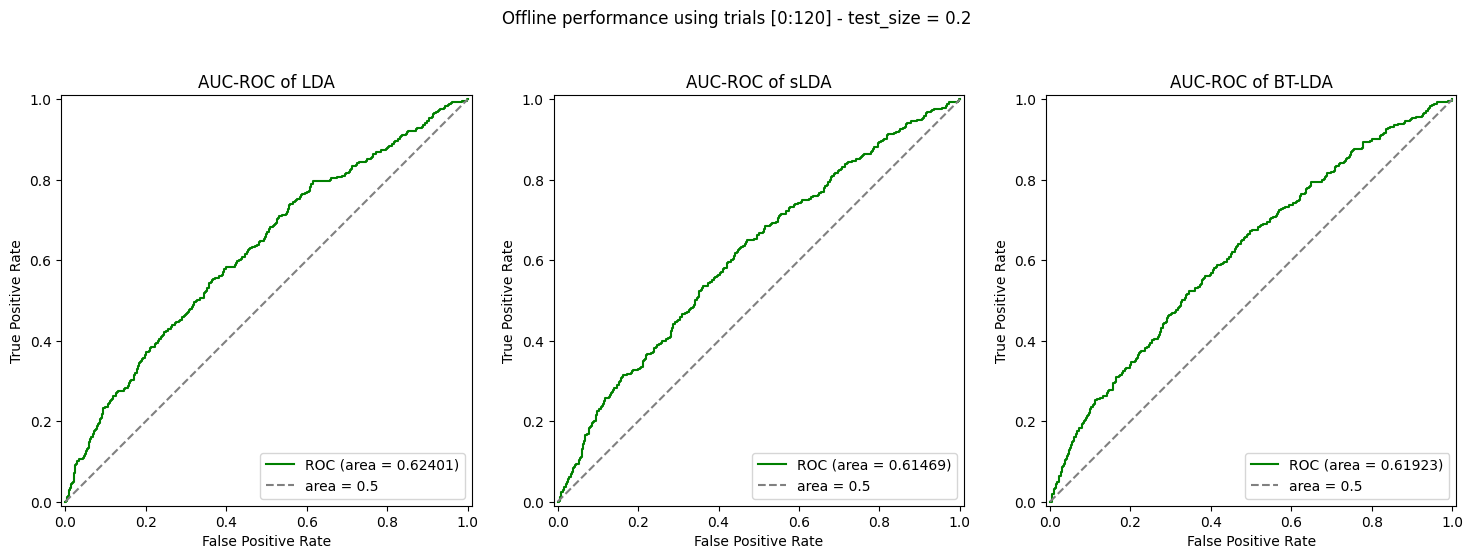

AUC scores computed using a 4-fold cross-validation
Mean AUC score of LDA: 		 0.6256225801700193
Mean AUC score of sLDA: 	 0.6217392791010857
Mean AUC score of BT-LDA: 	 0.6252077897483377
trial 0/120
trial 1/120
trial 2/120
trial 3/120
trial 4/120
trial 5/120
trial 6/120
trial 7/120
trial 8/120
trial 9/120
trial 10/120
trial 11/120
trial 12/120
trial 13/120
trial 14/120
trial 15/120
trial 16/120
trial 17/120
trial 18/120
trial 19/120
trial 20/120
trial 21/120
trial 22/120
trial 23/120
trial 24/120
trial 25/120
trial 26/120
trial 27/120
trial 28/120
trial 29/120
trial 30/120
trial 31/120
trial 32/120
trial 33/120
trial 34/120
trial 35/120
trial 36/120
trial 37/120
trial 38/120
trial 39/120
trial 40/120
trial 41/120
trial 42/120
trial 43/120
trial 44/120
trial 45/120
trial 46/120
trial 47/120
trial 48/120
trial 49/120
trial 50/120
trial 51/120
trial 52/120
trial 53/120
trial 54/120
trial 55/120
trial 56/120
trial 57/120
trial 58/120
trial 59/120
trial 60/120
trial 61/120
trial 62/120
tr

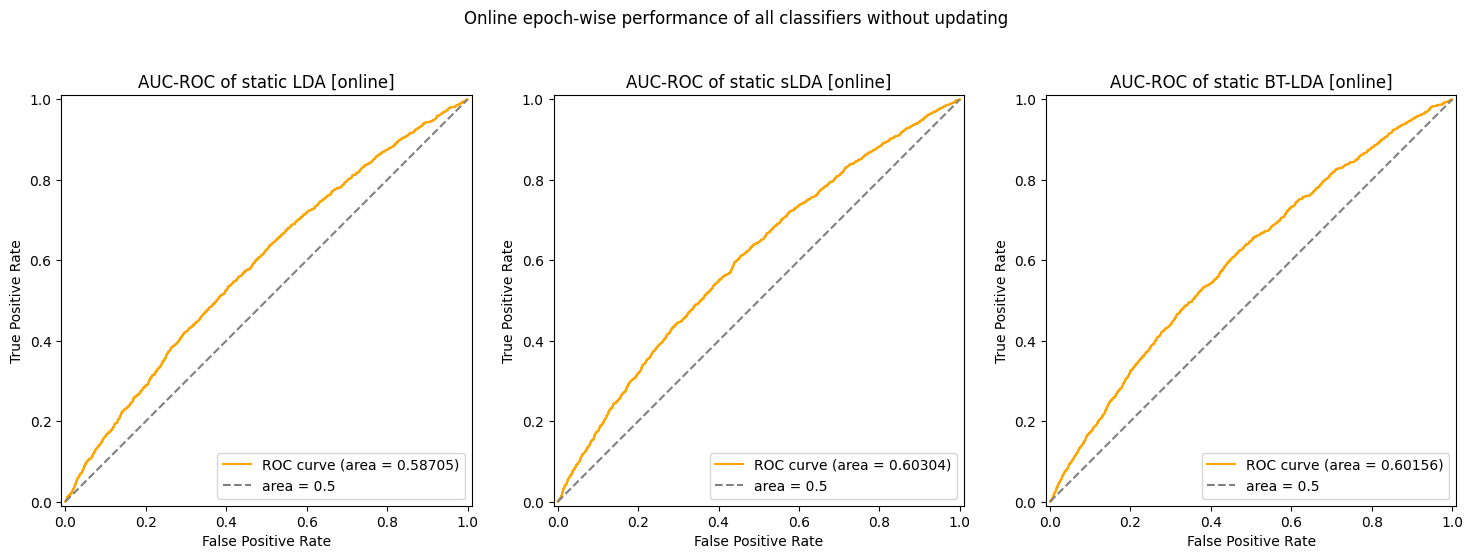

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.50000
Accuracy SLDA: 0.53333
Accuracy BT-LDA: 0.52500
trial 0/120
trial 1/120
trial 2/120
trial 3/120
trial 4/120
trial 5/120
trial 6/120
trial 7/120
trial 8/120
trial 9/120
trial 10/120
trial 11/120
trial 12/120
trial 13/120
trial 14/120
trial 15/120
trial 16/120
trial 17/120
trial 18/120
trial 19/120
trial 20/120
trial 21/120
trial 22/120
trial 23/120
trial 24/120
trial 25/120
trial 26/120
trial 27/120
trial 28/120
trial 29/120
trial 30/120
trial 31/120
trial 32/120
trial 33/120
trial 34/120
trial 35/120
trial 36/120
trial 37/120
trial 38/120
trial 39/120
trial 40/120
trial 41/120
trial 42/120
trial 43/120
trial 44/120
trial 45/120
trial 46/120
trial 47/120
trial 48/120
trial 49/120
trial 50/120
trial 51/120
trial 52/120
trial 53/120
trial 54/120
trial 55/120
trial 56/120
trial 57/120
trial 58/120
trial 59/120
trial 60/120
trial 61/120
trial 62/120
trial 63/120
trial 64/120
trial 65/120
tria

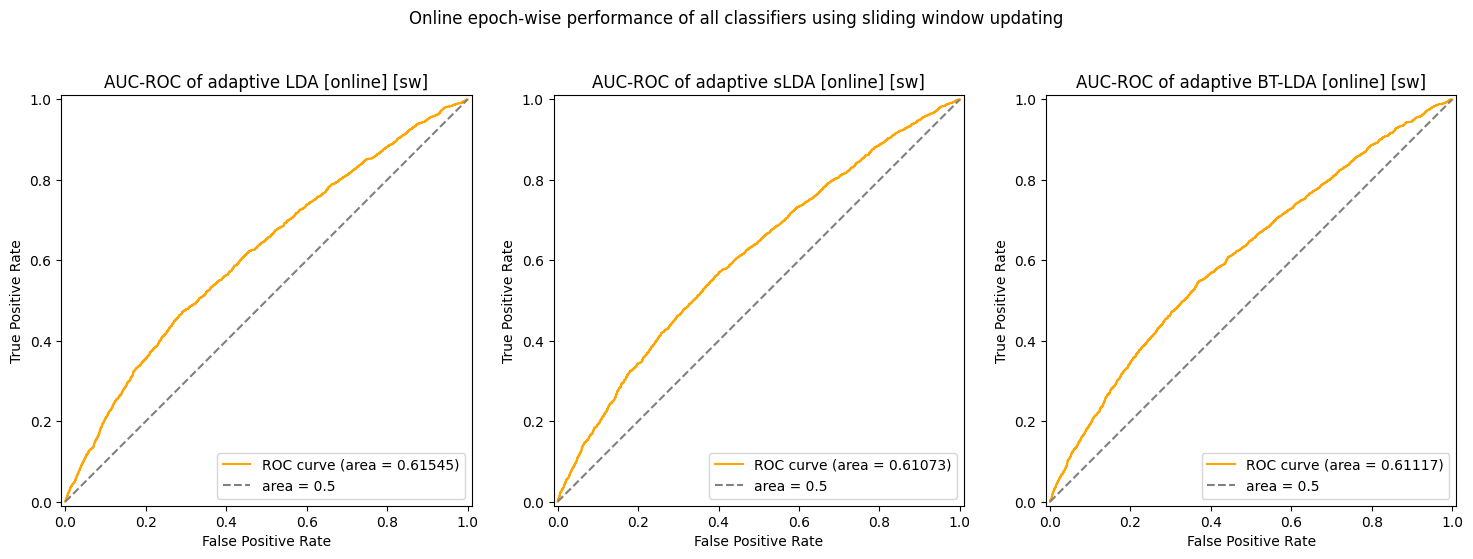

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.59167
Accuracy SLDA: 0.60833
Accuracy BT-LDA: 0.61667
Loading file:  B:_anonymized_data_P02a_P2_S4_anonymized
Corresponding .pkl file:  B:_anonymized_data_P02a_P2_S4_anonymized.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P02a_P2_S4_anonymized.pkl
Loading file:  B:_anonymized_data_P02a_P2_S5_anonymized
Corresponding .pkl file:  B:_anonymized_data_P02a_P2_S5_anonymized.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P02a_P2_S5_anonymized.pkl
AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.6273308367768595
AUC SLDA:  0.6168985666322314
AUC BT-LDA:  0.6201139591942149


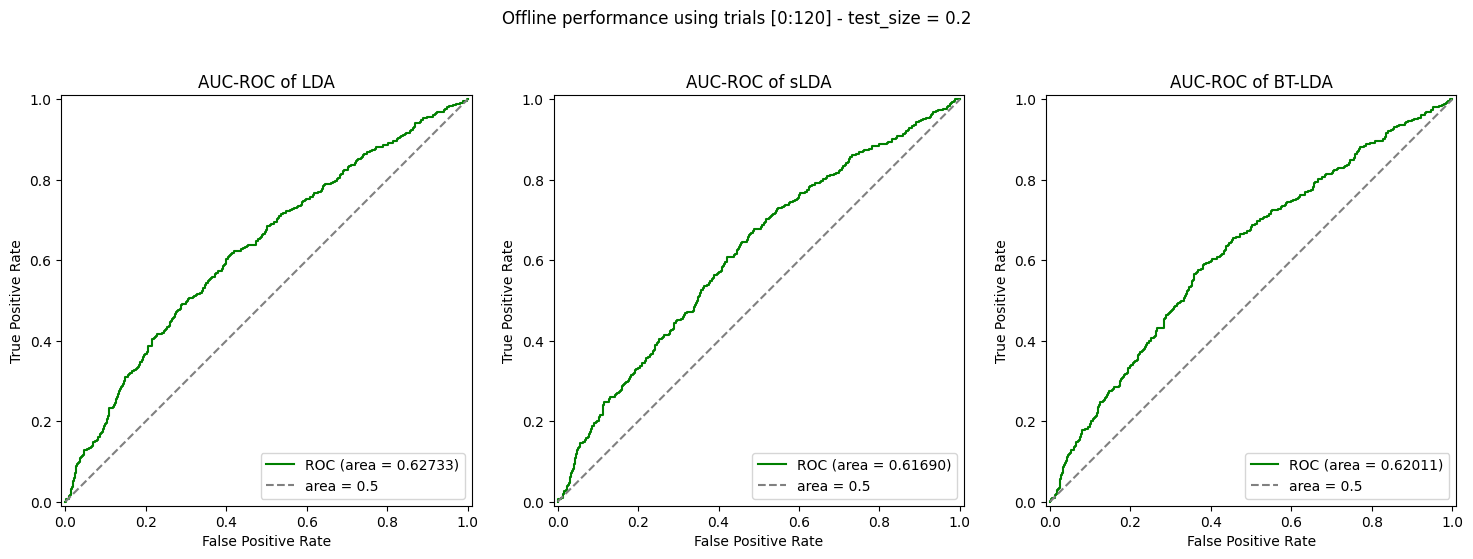

AUC scores computed using a 4-fold cross-validation
Mean AUC score of LDA: 		 0.620410382231405
Mean AUC score of sLDA: 	 0.6145470041322314
Mean AUC score of BT-LDA: 	 0.6164677169421487
trial 0/138
trial 1/138
trial 2/138
trial 3/138
trial 4/138
trial 5/138
trial 6/138
trial 7/138
trial 8/138
trial 9/138
trial 10/138
trial 11/138
trial 12/138
trial 13/138
trial 14/138
trial 15/138
trial 16/138
trial 17/138
trial 18/138
trial 19/138
trial 20/138
trial 21/138
trial 22/138
trial 23/138
trial 24/138
trial 25/138
trial 26/138
trial 27/138
trial 28/138
trial 29/138
trial 30/138
trial 31/138
trial 32/138
trial 33/138
trial 34/138
trial 35/138
trial 36/138
trial 37/138
trial 38/138
trial 39/138
trial 40/138
trial 41/138
trial 42/138
trial 43/138
trial 44/138
trial 45/138
trial 46/138
trial 47/138
trial 48/138
trial 49/138
trial 50/138
trial 51/138
trial 52/138
trial 53/138
trial 54/138
trial 55/138
trial 56/138
trial 57/138
trial 58/138
trial 59/138
trial 60/138
trial 61/138
trial 62/138
tri

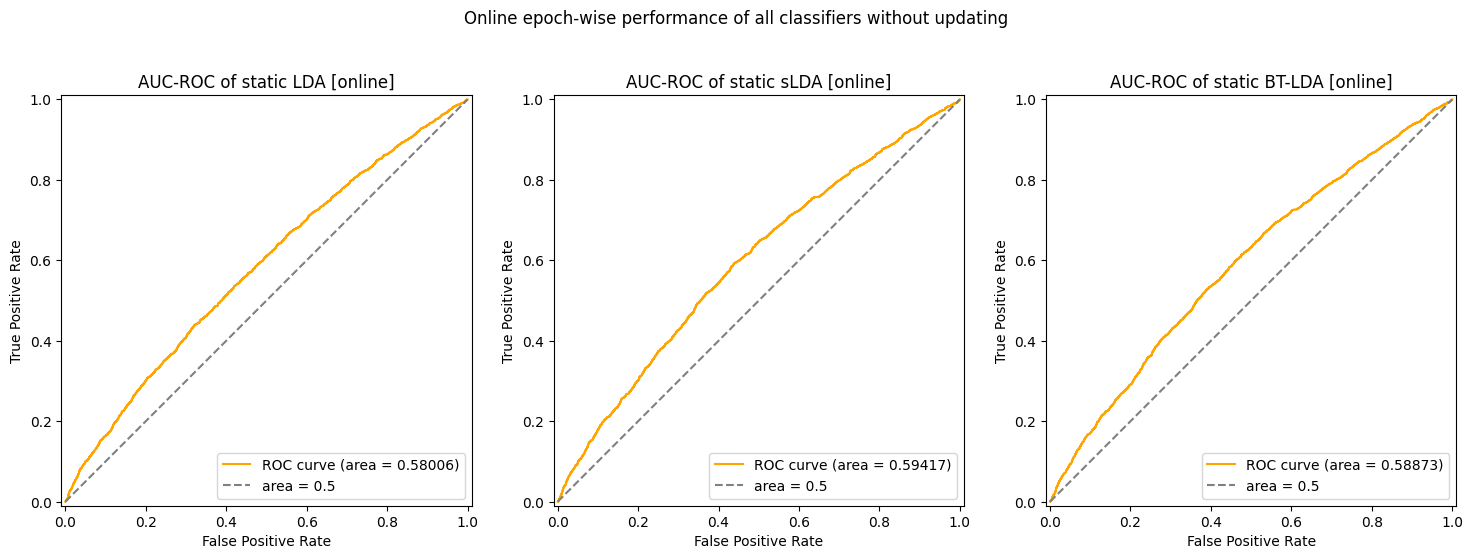

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.47826
Accuracy SLDA: 0.54348
Accuracy BT-LDA: 0.50725
trial 0/138
trial 1/138
trial 2/138
trial 3/138
trial 4/138
trial 5/138
trial 6/138
trial 7/138
trial 8/138
trial 9/138
trial 10/138
trial 11/138
trial 12/138
trial 13/138
trial 14/138
trial 15/138
trial 16/138
trial 17/138
trial 18/138
trial 19/138
trial 20/138
trial 21/138
trial 22/138
trial 23/138
trial 24/138
trial 25/138
trial 26/138
trial 27/138
trial 28/138
trial 29/138
trial 30/138
trial 31/138
trial 32/138
trial 33/138
trial 34/138
trial 35/138
trial 36/138
trial 37/138
trial 38/138
trial 39/138
trial 40/138
trial 41/138
trial 42/138
trial 43/138
trial 44/138
trial 45/138
trial 46/138
trial 47/138
trial 48/138
trial 49/138
trial 50/138
trial 51/138
trial 52/138
trial 53/138
trial 54/138
trial 55/138
trial 56/138
trial 57/138
trial 58/138
trial 59/138
trial 60/138
trial 61/138
trial 62/138
trial 63/138
trial 64/138
trial 65/138
tria

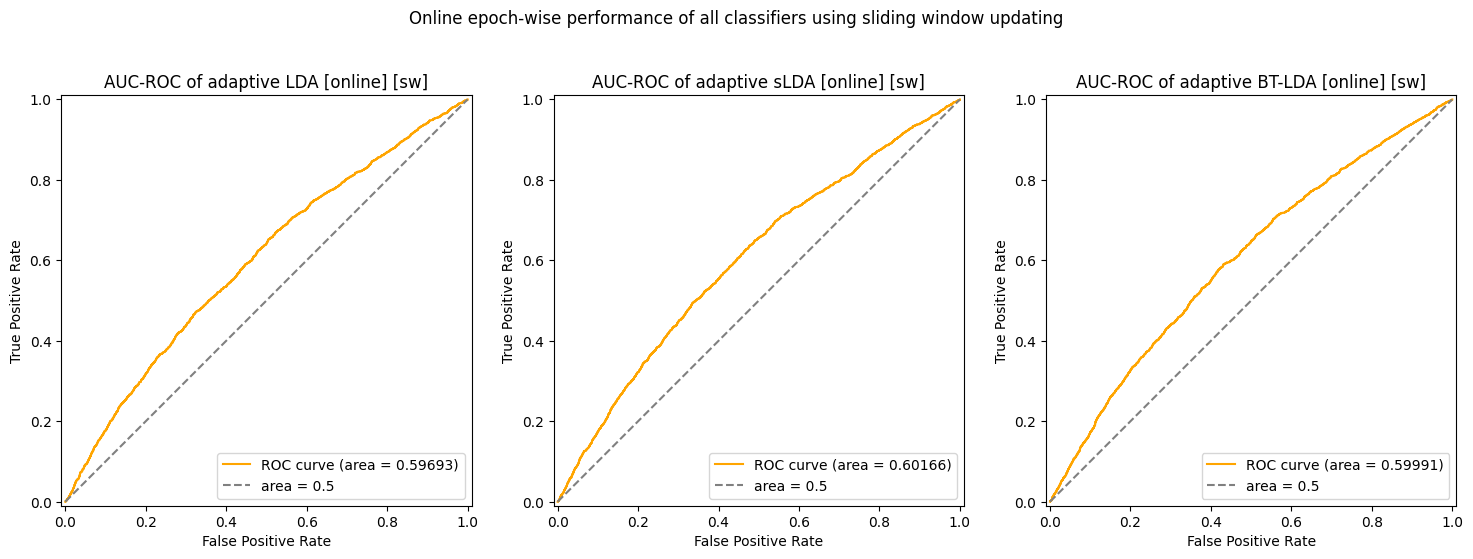

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.49275
Accuracy SLDA: 0.54348
Accuracy BT-LDA: 0.50725
Loading file:  B:_anonymized_data_P02a_P2_S5_anonymized
Corresponding .pkl file:  B:_anonymized_data_P02a_P2_S5_anonymized.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P02a_P2_S5_anonymized.pkl
Loading file:  B:_anonymized_data_P02a_P2_S6_anonymized
Corresponding .pkl file:  B:_anonymized_data_P02a_P2_S6_anonymized.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P02a_P2_S6_anonymized.pkl
AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.6047851560186402
AUC SLDA:  0.5991217658500297
AUC BT-LDA:  0.600822796655745


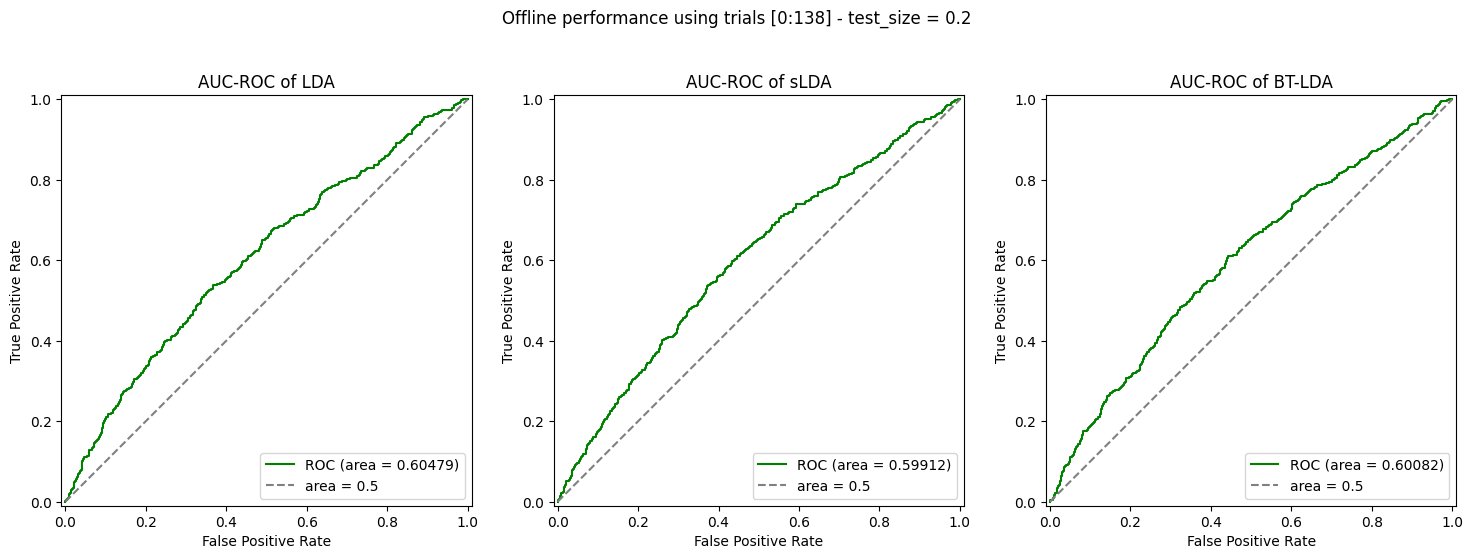

AUC scores computed using a 4-fold cross-validation
Mean AUC score of LDA: 		 0.6111242173026749
Mean AUC score of sLDA: 	 0.6097824930496444
Mean AUC score of BT-LDA: 	 0.6120409822432366
trial 0/114
trial 1/114
trial 2/114
trial 3/114
trial 4/114
trial 5/114
trial 6/114
trial 7/114
trial 8/114
trial 9/114
trial 10/114
trial 11/114
trial 12/114
trial 13/114
trial 14/114
trial 15/114
trial 16/114
trial 17/114
trial 18/114
trial 19/114
trial 20/114
trial 21/114
trial 22/114
trial 23/114
trial 24/114
trial 25/114
trial 26/114
trial 27/114
trial 28/114
trial 29/114
trial 30/114
trial 31/114
trial 32/114
trial 33/114
trial 34/114
trial 35/114
trial 36/114
trial 37/114
trial 38/114
trial 39/114
trial 40/114
trial 41/114
trial 42/114
trial 43/114
trial 44/114
trial 45/114
trial 46/114
trial 47/114
trial 48/114
trial 49/114
trial 50/114
trial 51/114
trial 52/114
trial 53/114
trial 54/114
trial 55/114
trial 56/114
trial 57/114
trial 58/114
trial 59/114
trial 60/114
trial 61/114
trial 62/114
tr

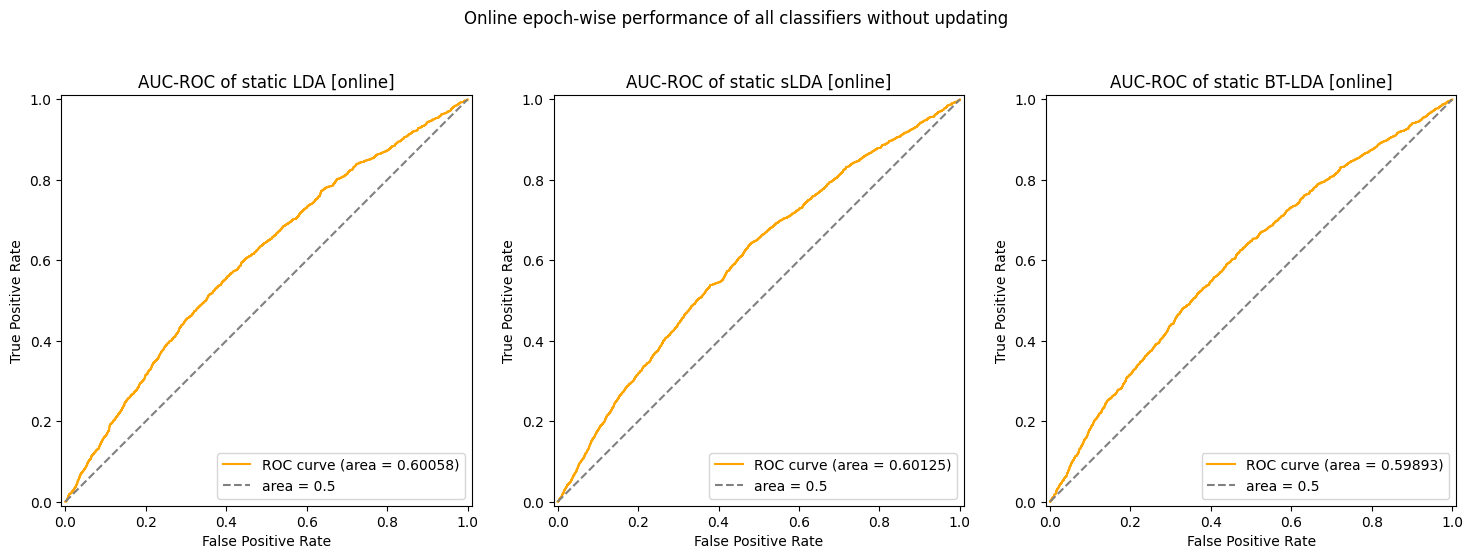

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.47368
Accuracy SLDA: 0.46491
Accuracy BT-LDA: 0.49123
trial 0/114
trial 1/114
trial 2/114
trial 3/114
trial 4/114
trial 5/114
trial 6/114
trial 7/114
trial 8/114
trial 9/114
trial 10/114
trial 11/114
trial 12/114
trial 13/114
trial 14/114
trial 15/114
trial 16/114
trial 17/114
trial 18/114
trial 19/114
trial 20/114
trial 21/114
trial 22/114
trial 23/114
trial 24/114
trial 25/114
trial 26/114
trial 27/114
trial 28/114
trial 29/114
trial 30/114
trial 31/114
trial 32/114
trial 33/114
trial 34/114
trial 35/114
trial 36/114
trial 37/114
trial 38/114
trial 39/114
trial 40/114
trial 41/114
trial 42/114
trial 43/114
trial 44/114
trial 45/114
trial 46/114
trial 47/114
trial 48/114
trial 49/114
trial 50/114
trial 51/114
trial 52/114
trial 53/114
trial 54/114
trial 55/114
trial 56/114
trial 57/114
trial 58/114
trial 59/114
trial 60/114
trial 61/114
trial 62/114
trial 63/114
trial 64/114
trial 65/114
tria

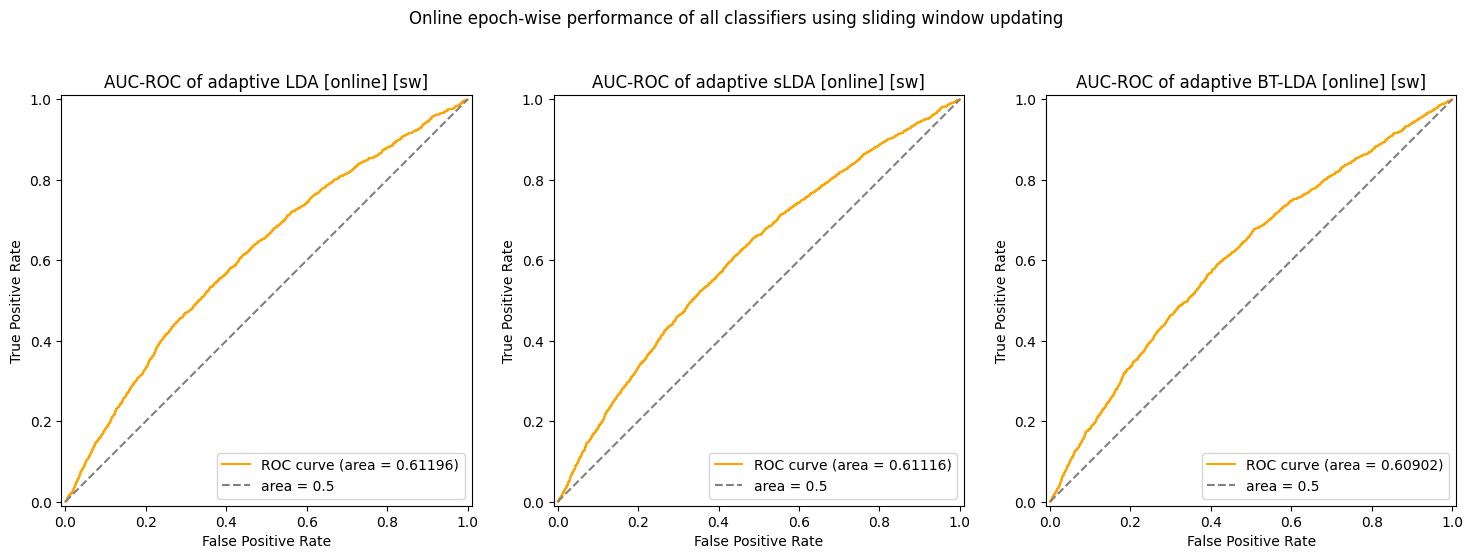

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.50877
Accuracy SLDA: 0.50000
Accuracy BT-LDA: 0.50000
Loading file:  B:_anonymized_data_P02a_P2_S6_anonymized
Corresponding .pkl file:  B:_anonymized_data_P02a_P2_S6_anonymized.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P02a_P2_S6_anonymized.pkl
Loading file:  B:_anonymized_data_P02a_P2_S7_anonymized
Corresponding .pkl file:  B:_anonymized_data_P02a_P2_S7_anonymized.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P02a_P2_S7_anonymized.pkl
AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.6202190773333611
AUC SLDA:  0.6247506341575212
AUC BT-LDA:  0.6179619800646226


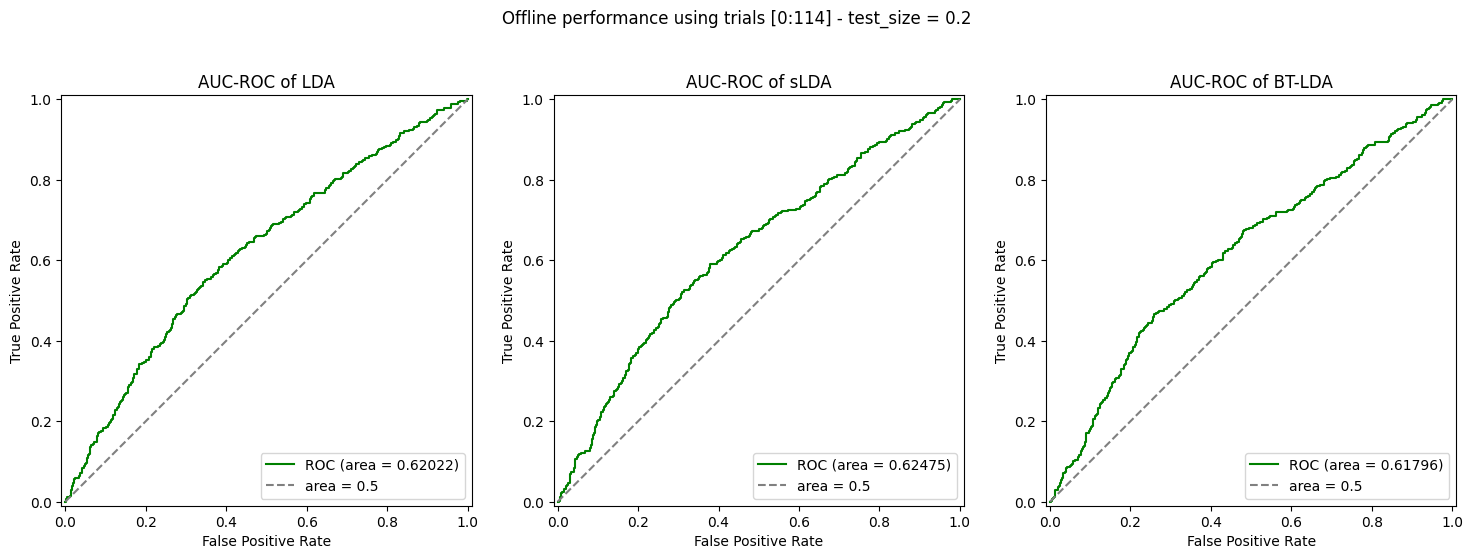

AUC scores computed using a 4-fold cross-validation
Mean AUC score of LDA: 		 0.626128210358424
Mean AUC score of sLDA: 	 0.6169139177263543
Mean AUC score of BT-LDA: 	 0.6185234383302786
trial 0/84
trial 1/84
trial 2/84
trial 3/84
trial 4/84
trial 5/84
trial 6/84
trial 7/84
trial 8/84
trial 9/84
trial 10/84
trial 11/84
trial 12/84
trial 13/84
trial 14/84
trial 15/84
trial 16/84
trial 17/84
trial 18/84
trial 19/84
trial 20/84
trial 21/84
trial 22/84
trial 23/84
trial 24/84
trial 25/84
trial 26/84
trial 27/84
trial 28/84
trial 29/84
trial 30/84
trial 31/84
trial 32/84
trial 33/84
trial 34/84
trial 35/84
trial 36/84
trial 37/84
trial 38/84
trial 39/84
trial 40/84
trial 41/84
trial 42/84
trial 43/84
trial 44/84
trial 45/84
trial 46/84
trial 47/84
trial 48/84
trial 49/84
trial 50/84
trial 51/84
trial 52/84
trial 53/84
trial 54/84
trial 55/84
trial 56/84
trial 57/84
trial 58/84
trial 59/84
trial 60/84
trial 61/84
trial 62/84
trial 63/84
trial 64/84
trial 65/84
trial 66/84
trial 67/84
trial 

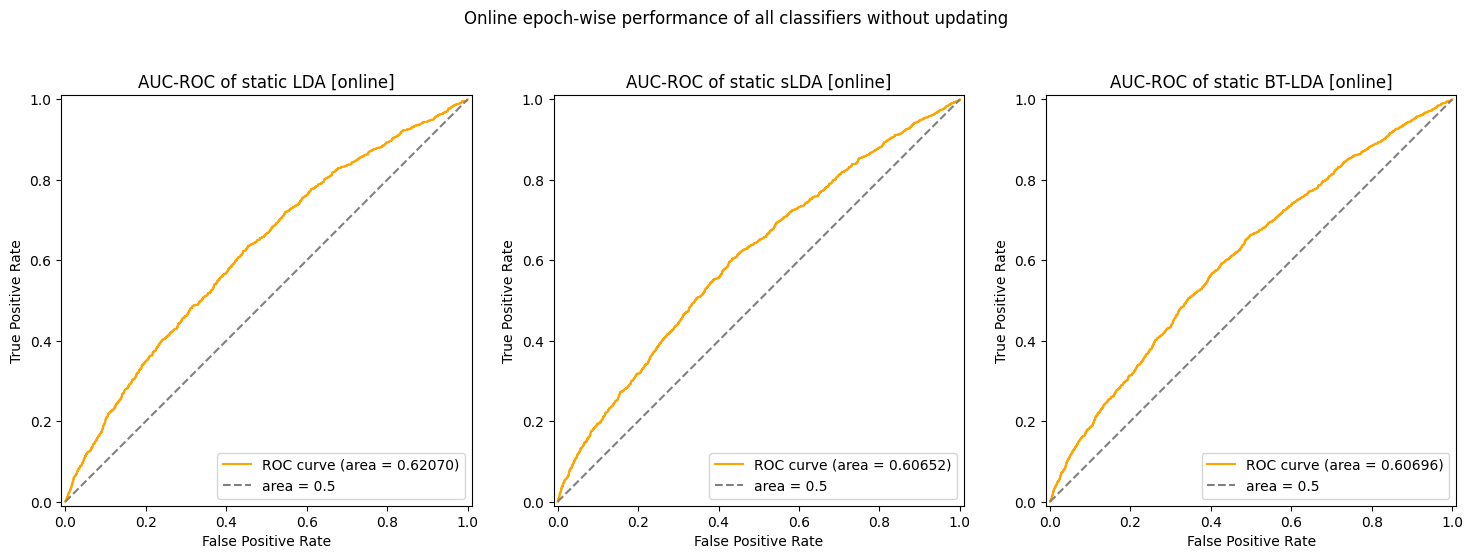

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.64286
Accuracy SLDA: 0.61905
Accuracy BT-LDA: 0.58333
trial 0/84
trial 1/84
trial 2/84
trial 3/84
trial 4/84
trial 5/84
trial 6/84
trial 7/84
trial 8/84
trial 9/84
trial 10/84
trial 11/84
trial 12/84
trial 13/84
trial 14/84
trial 15/84
trial 16/84
trial 17/84
trial 18/84
trial 19/84
trial 20/84
trial 21/84
trial 22/84
trial 23/84
trial 24/84
trial 25/84
trial 26/84
trial 27/84
trial 28/84
trial 29/84
trial 30/84
trial 31/84
trial 32/84
trial 33/84
trial 34/84
trial 35/84
trial 36/84
trial 37/84
trial 38/84
trial 39/84
trial 40/84
trial 41/84
trial 42/84
trial 43/84
trial 44/84
trial 45/84
trial 46/84
trial 47/84
trial 48/84
trial 49/84
trial 50/84
trial 51/84
trial 52/84
trial 53/84
trial 54/84
trial 55/84
trial 56/84
trial 57/84
trial 58/84
trial 59/84
trial 60/84
trial 61/84
trial 62/84
trial 63/84
trial 64/84
trial 65/84
trial 66/84
trial 67/84
trial 68/84
trial 69/84
trial 70/84
trial 71/8

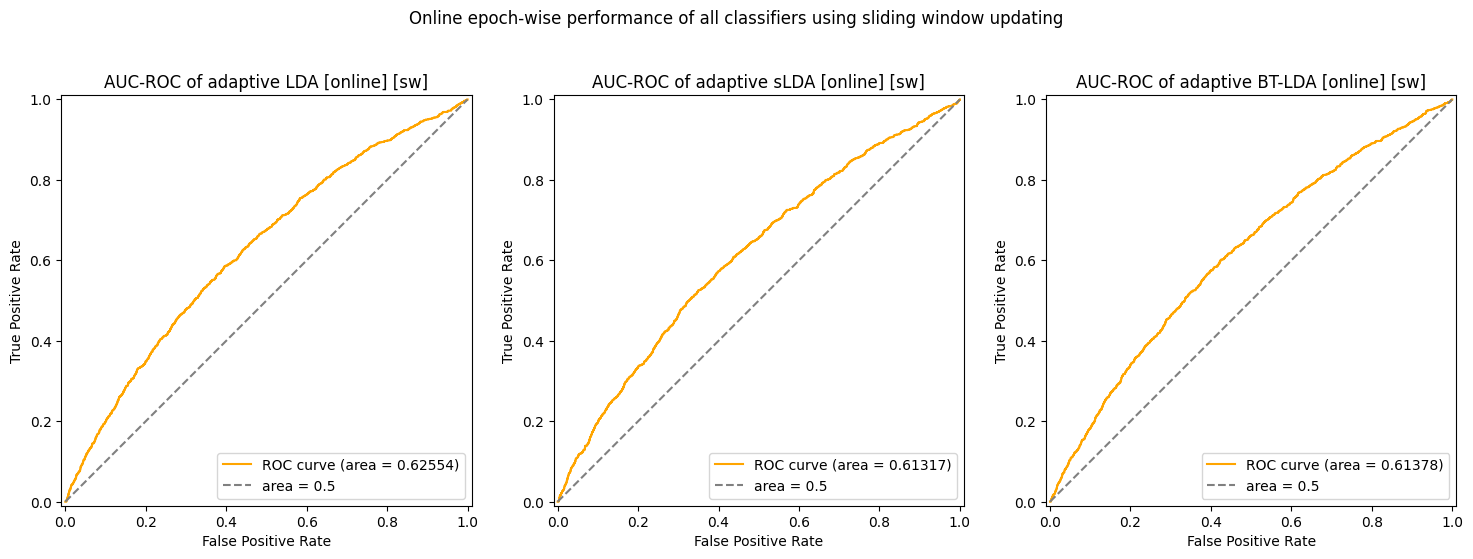

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.67857
Accuracy SLDA: 0.61905
Accuracy BT-LDA: 0.64286
Loading file:  B:_anonymized_data_P02a_P2_S7_anonymized
Corresponding .pkl file:  B:_anonymized_data_P02a_P2_S7_anonymized.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P02a_P2_S7_anonymized.pkl
Loading file:  B:_anonymized_data_P02a_P2_S8_anonymized
Corresponding .pkl file:  B:_anonymized_data_P02a_P2_S8_anonymized.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P02a_P2_S8_anonymized.pkl
AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.658374764848159
AUC SLDA:  0.6586334318731524
AUC BT-LDA:  0.6652949475947326


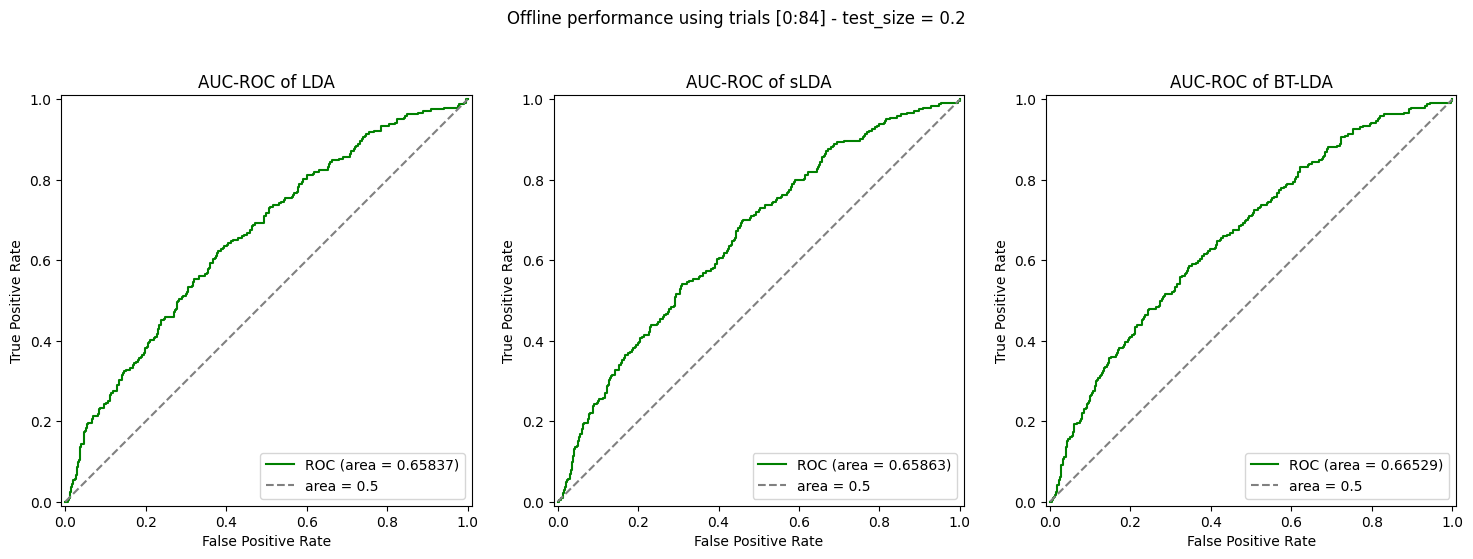

AUC scores computed using a 4-fold cross-validation
Mean AUC score of LDA: 		 0.6371652781510346
Mean AUC score of sLDA: 	 0.6154157484547165
Mean AUC score of BT-LDA: 	 0.623352324643913
trial 0/108
trial 1/108
trial 2/108
trial 3/108
trial 4/108
trial 5/108
trial 6/108
trial 7/108
trial 8/108
trial 9/108
trial 10/108
trial 11/108
trial 12/108
trial 13/108
trial 14/108
trial 15/108
trial 16/108
trial 17/108
trial 18/108
trial 19/108
trial 20/108
trial 21/108
trial 22/108
trial 23/108
trial 24/108
trial 25/108
trial 26/108
trial 27/108
trial 28/108
trial 29/108
trial 30/108
trial 31/108
trial 32/108
trial 33/108
trial 34/108
trial 35/108
trial 36/108
trial 37/108
trial 38/108
trial 39/108
trial 40/108
trial 41/108
trial 42/108
trial 43/108
trial 44/108
trial 45/108
trial 46/108
trial 47/108
trial 48/108
trial 49/108
trial 50/108
trial 51/108
trial 52/108
trial 53/108
trial 54/108
trial 55/108
trial 56/108
trial 57/108
trial 58/108
trial 59/108
trial 60/108
trial 61/108
trial 62/108
tri

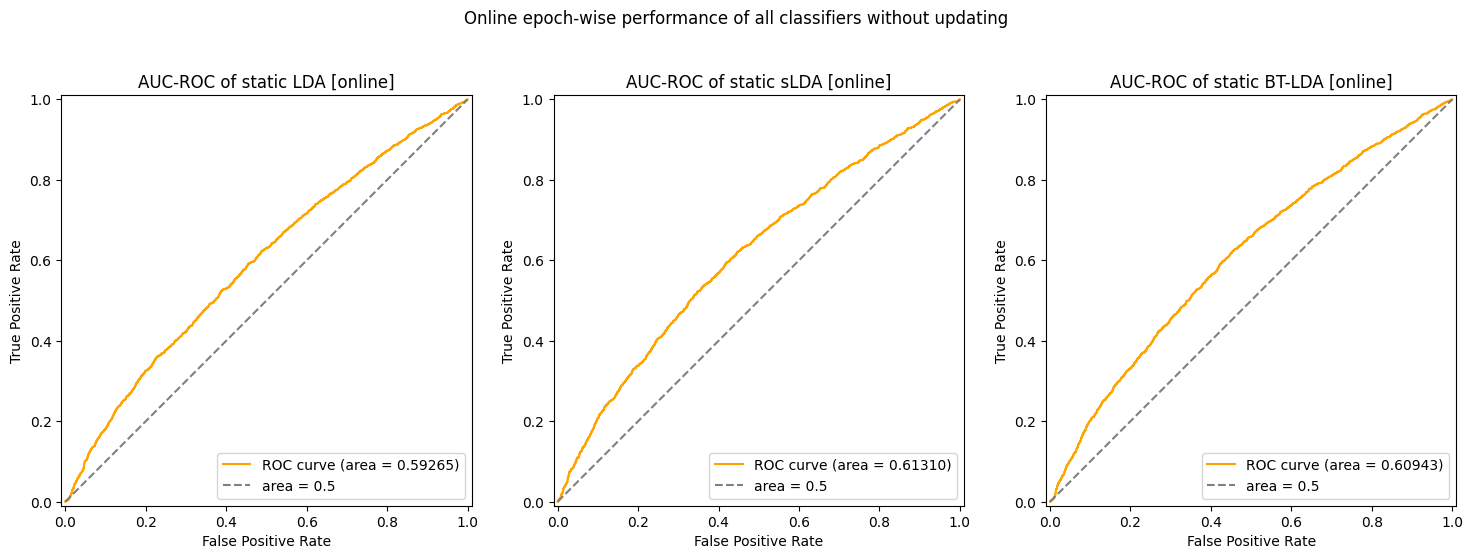

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.46296
Accuracy SLDA: 0.57407
Accuracy BT-LDA: 0.53704
trial 0/108
trial 1/108
trial 2/108
trial 3/108
trial 4/108
trial 5/108
trial 6/108
trial 7/108
trial 8/108
trial 9/108
trial 10/108
trial 11/108
trial 12/108
trial 13/108
trial 14/108
trial 15/108
trial 16/108
trial 17/108
trial 18/108
trial 19/108
trial 20/108
trial 21/108
trial 22/108
trial 23/108
trial 24/108
trial 25/108
trial 26/108
trial 27/108
trial 28/108
trial 29/108
trial 30/108
trial 31/108
trial 32/108
trial 33/108
trial 34/108
trial 35/108
trial 36/108
trial 37/108
trial 38/108
trial 39/108
trial 40/108
trial 41/108
trial 42/108
trial 43/108
trial 44/108
trial 45/108
trial 46/108
trial 47/108
trial 48/108
trial 49/108
trial 50/108
trial 51/108
trial 52/108
trial 53/108
trial 54/108
trial 55/108
trial 56/108
trial 57/108
trial 58/108
trial 59/108
trial 60/108
trial 61/108
trial 62/108
trial 63/108
trial 64/108
trial 65/108
tria

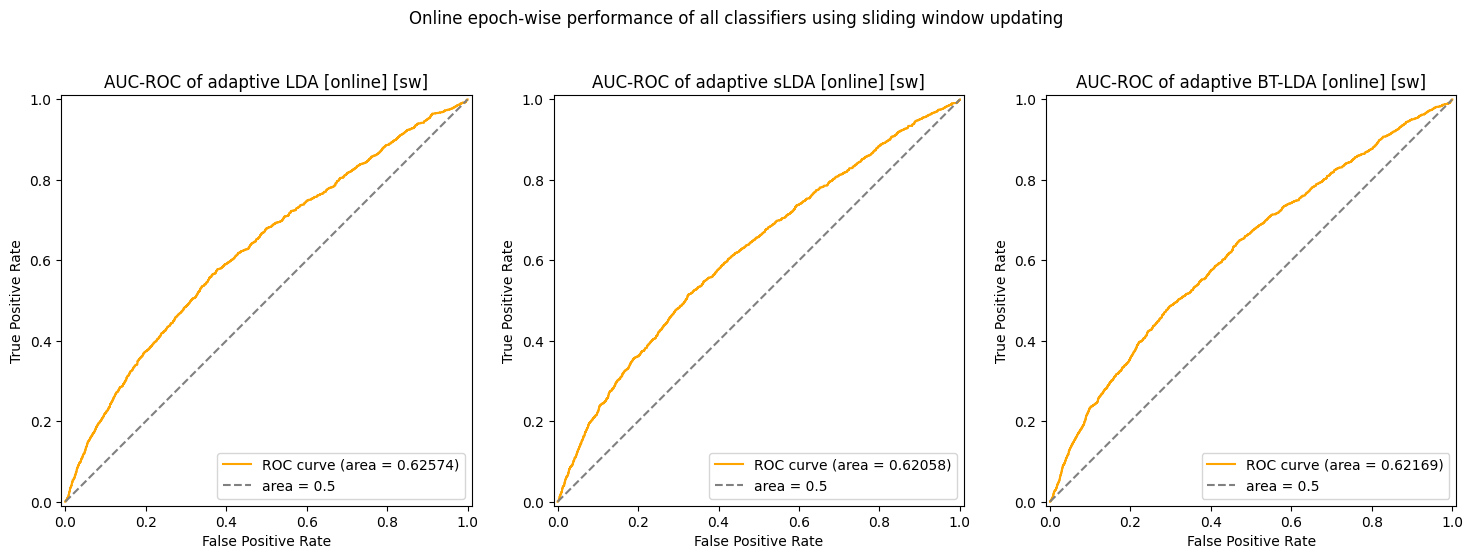

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.65741
Accuracy SLDA: 0.66667
Accuracy BT-LDA: 0.62037
Loading file:  B:_anonymized_data_P02a_P2_S8_anonymized
Corresponding .pkl file:  B:_anonymized_data_P02a_P2_S8_anonymized.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P02a_P2_S8_anonymized.pkl
Loading file:  B:_anonymized_data_P02a_P2_S9_anonymized
Corresponding .pkl file:  B:_anonymized_data_P02a_P2_S9_anonymized.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P02a_P2_S9_anonymized.pkl
AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.6177125308722216
AUC SLDA:  0.619158650721435
AUC BT-LDA:  0.6192967632913038


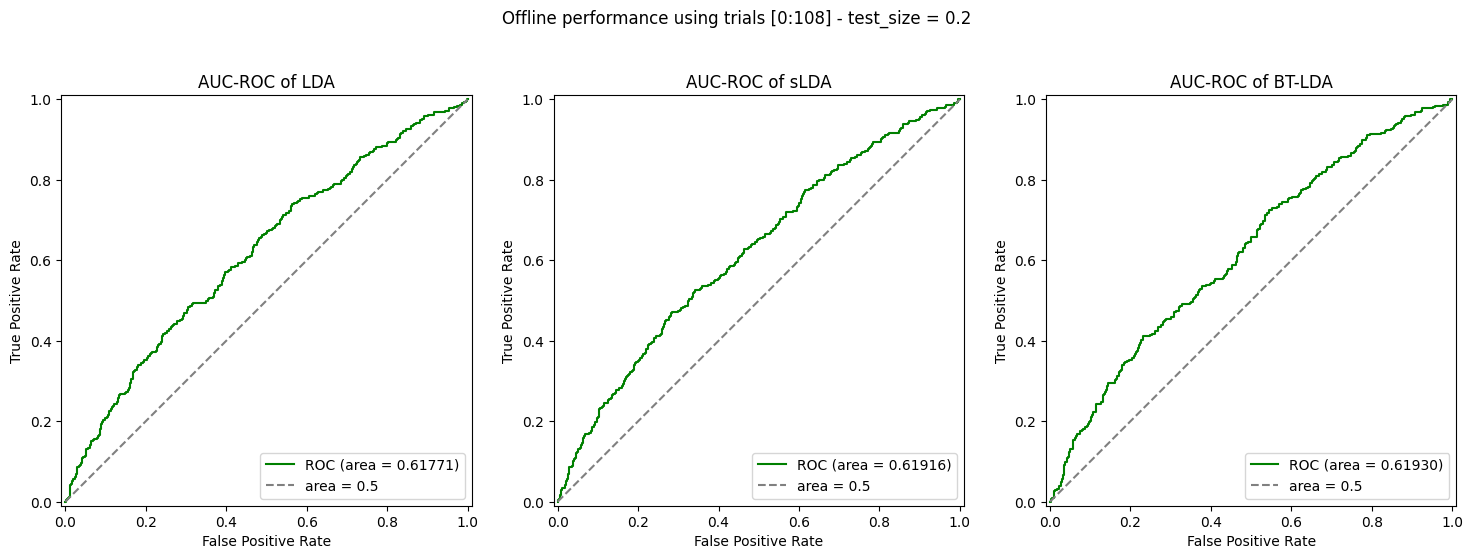

AUC scores computed using a 4-fold cross-validation
Mean AUC score of LDA: 		 0.630168744793836
Mean AUC score of sLDA: 	 0.6271283449604331
Mean AUC score of BT-LDA: 	 0.6276154466888797
trial 0/84
trial 1/84
trial 2/84
trial 3/84
trial 4/84
trial 5/84
trial 6/84
trial 7/84
trial 8/84
trial 9/84
trial 10/84
trial 11/84
trial 12/84
trial 13/84
trial 14/84
trial 15/84
trial 16/84
trial 17/84
trial 18/84
trial 19/84
trial 20/84
trial 21/84
trial 22/84
trial 23/84
trial 24/84
trial 25/84
trial 26/84
trial 27/84
trial 28/84
trial 29/84
trial 30/84
trial 31/84
trial 32/84
trial 33/84
trial 34/84
trial 35/84
trial 36/84
trial 37/84
trial 38/84
trial 39/84
trial 40/84
trial 41/84
trial 42/84
trial 43/84
trial 44/84
trial 45/84
trial 46/84
trial 47/84
trial 48/84
trial 49/84
trial 50/84
trial 51/84
trial 52/84
trial 53/84
trial 54/84
trial 55/84
trial 56/84
trial 57/84
trial 58/84
trial 59/84
trial 60/84
trial 61/84
trial 62/84
trial 63/84
trial 64/84
trial 65/84
trial 66/84
trial 67/84
trial 

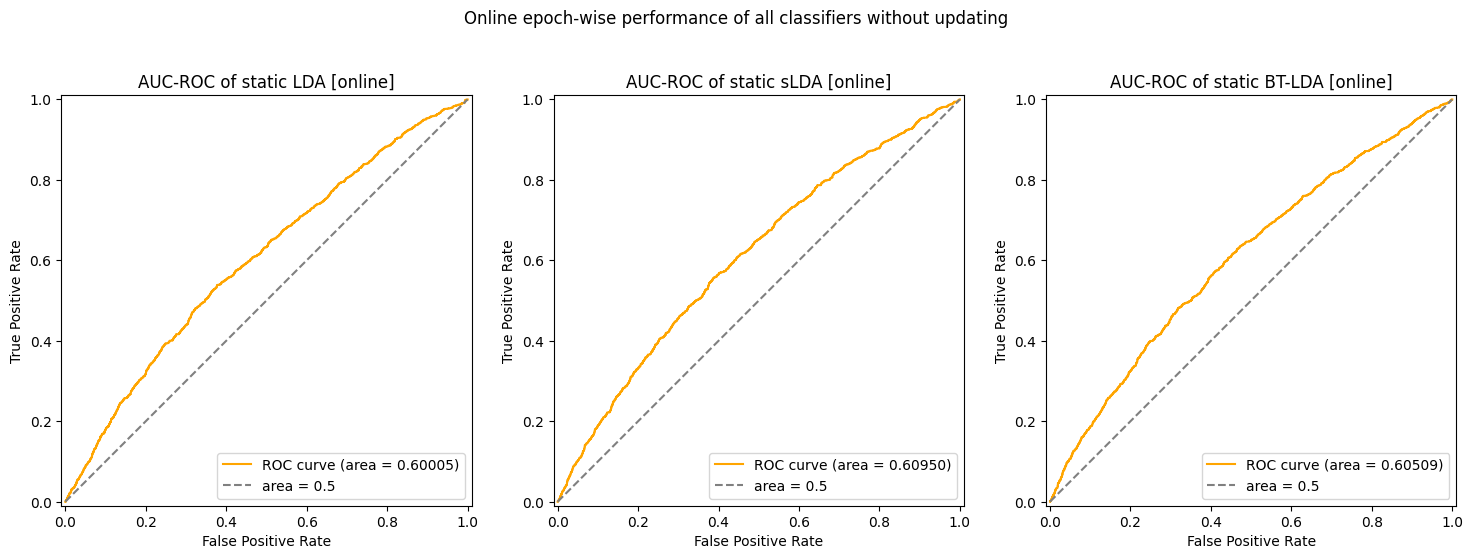

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.52381
Accuracy SLDA: 0.58333
Accuracy BT-LDA: 0.57143
trial 0/84
trial 1/84
trial 2/84
trial 3/84
trial 4/84
trial 5/84
trial 6/84
trial 7/84
trial 8/84
trial 9/84
trial 10/84
trial 11/84
trial 12/84
trial 13/84
trial 14/84
trial 15/84
trial 16/84
trial 17/84
trial 18/84
trial 19/84
trial 20/84
trial 21/84
trial 22/84
trial 23/84
trial 24/84
trial 25/84
trial 26/84
trial 27/84
trial 28/84
trial 29/84
trial 30/84
trial 31/84
trial 32/84
trial 33/84
trial 34/84
trial 35/84
trial 36/84
trial 37/84
trial 38/84
trial 39/84
trial 40/84
trial 41/84
trial 42/84
trial 43/84
trial 44/84
trial 45/84
trial 46/84
trial 47/84
trial 48/84
trial 49/84
trial 50/84
trial 51/84
trial 52/84
trial 53/84
trial 54/84
trial 55/84
trial 56/84
trial 57/84
trial 58/84
trial 59/84
trial 60/84
trial 61/84
trial 62/84
trial 63/84
trial 64/84
trial 65/84
trial 66/84
trial 67/84
trial 68/84
trial 69/84
trial 70/84
trial 71/8

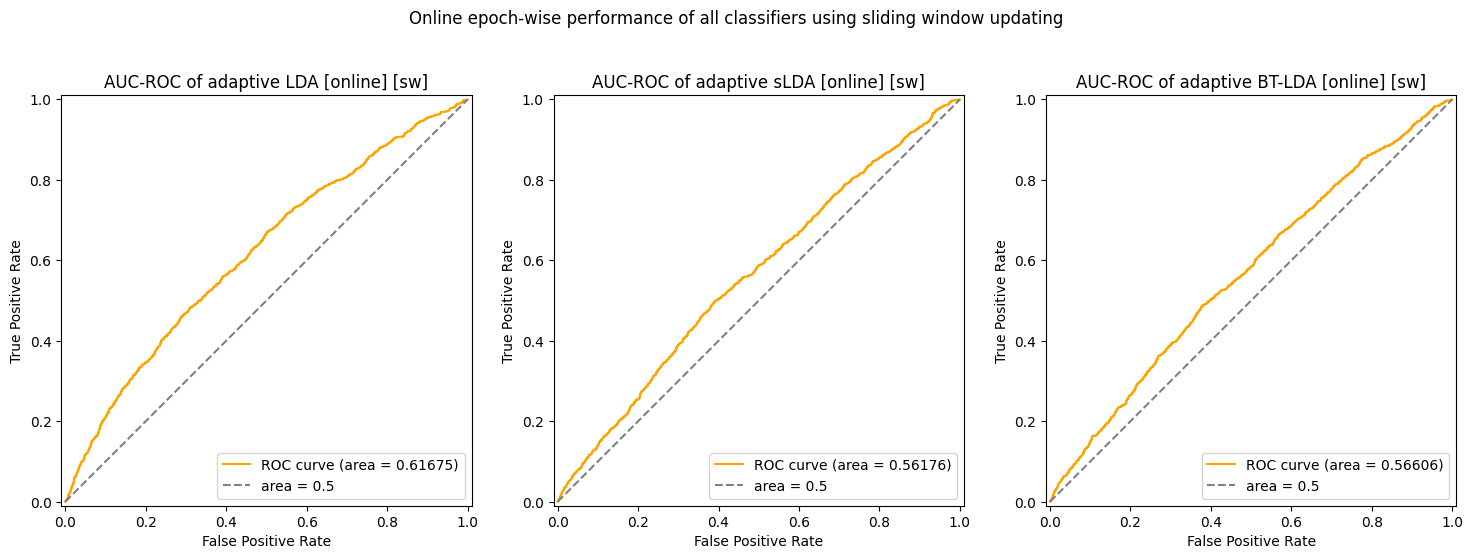

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.55952
Accuracy SLDA: 0.39286
Accuracy BT-LDA: 0.40476
Loading file:  B:_anonymized_data_P02a_P2_S9_anonymized
Corresponding .pkl file:  B:_anonymized_data_P02a_P2_S9_anonymized.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P02a_P2_S9_anonymized.pkl
Loading file:  B:_anonymized_data_P02a_P2_S10_anonymized
Corresponding .pkl file:  B:_anonymized_data_P02a_P2_S10_anonymized.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P02a_P2_S10_anonymized.pkl
AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.6288890624593195
AUC SLDA:  0.5754152672550704
AUC BT-LDA:  0.5770717800515505


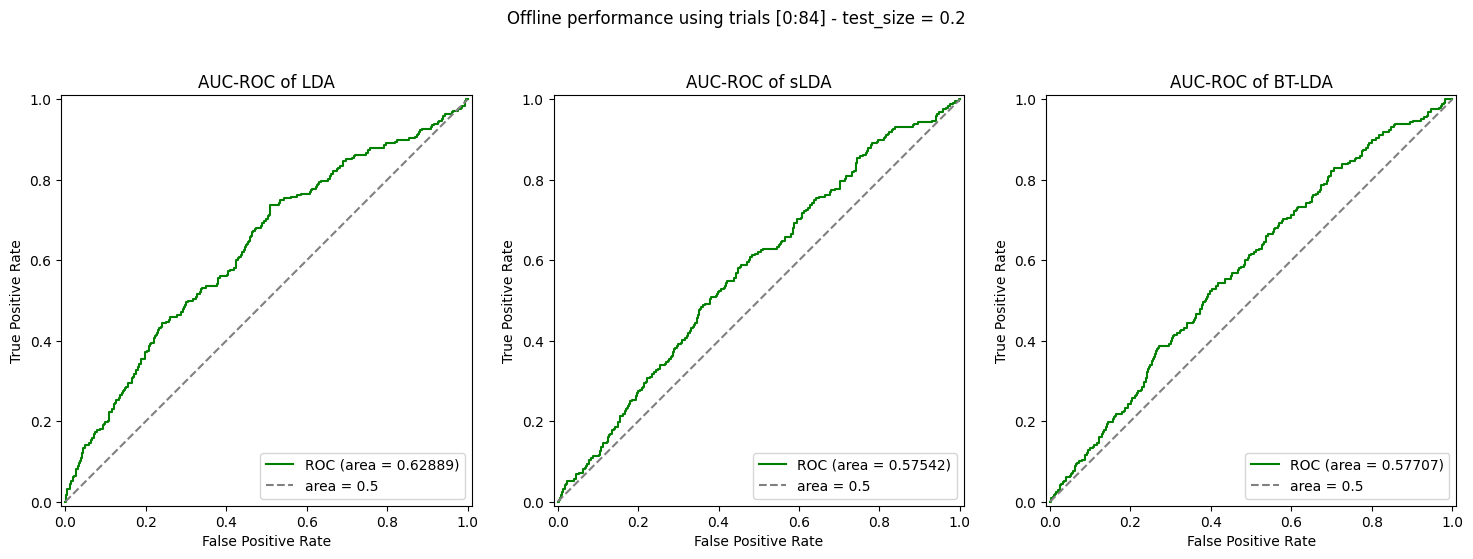

AUC scores computed using a 4-fold cross-validation
Mean AUC score of LDA: 		 0.6242472336071769
Mean AUC score of sLDA: 	 0.5669945294743776
Mean AUC score of BT-LDA: 	 0.5738302081581828
trial 0/126
trial 1/126
trial 2/126
trial 3/126
trial 4/126
trial 5/126
trial 6/126
trial 7/126
trial 8/126
trial 9/126
trial 10/126
trial 11/126
trial 12/126
trial 13/126
trial 14/126
trial 15/126
trial 16/126
trial 17/126
trial 18/126
trial 19/126
trial 20/126
trial 21/126
trial 22/126
trial 23/126
trial 24/126
trial 25/126
trial 26/126
trial 27/126
trial 28/126
trial 29/126
trial 30/126
trial 31/126
trial 32/126
trial 33/126
trial 34/126
trial 35/126
trial 36/126
trial 37/126
trial 38/126
trial 39/126
trial 40/126
trial 41/126
trial 42/126
trial 43/126
trial 44/126
trial 45/126
trial 46/126
trial 47/126
trial 48/126
trial 49/126
trial 50/126
trial 51/126
trial 52/126
trial 53/126
trial 54/126
trial 55/126
trial 56/126
trial 57/126
trial 58/126
trial 59/126
trial 60/126
trial 61/126
trial 62/126
tr

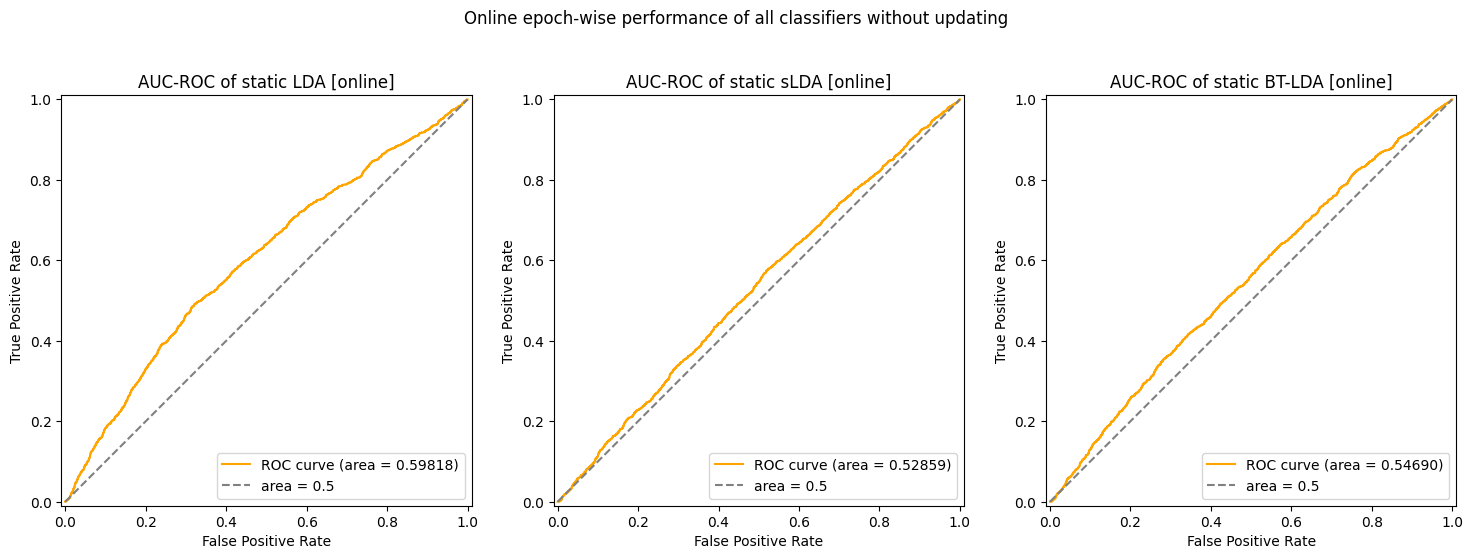

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.47619
Accuracy SLDA: 0.18254
Accuracy BT-LDA: 0.26190
trial 0/126
trial 1/126
trial 2/126
trial 3/126
trial 4/126
trial 5/126
trial 6/126
trial 7/126
trial 8/126
trial 9/126
trial 10/126
trial 11/126
trial 12/126
trial 13/126
trial 14/126
trial 15/126
trial 16/126
trial 17/126
trial 18/126
trial 19/126
trial 20/126
trial 21/126
trial 22/126
trial 23/126
trial 24/126
trial 25/126
trial 26/126
trial 27/126
trial 28/126
trial 29/126
trial 30/126
trial 31/126
trial 32/126
trial 33/126
trial 34/126
trial 35/126
trial 36/126
trial 37/126
trial 38/126
trial 39/126
trial 40/126
trial 41/126
trial 42/126
trial 43/126
trial 44/126
trial 45/126
trial 46/126
trial 47/126
trial 48/126
trial 49/126
trial 50/126
trial 51/126
trial 52/126
trial 53/126
trial 54/126
trial 55/126
trial 56/126
trial 57/126
trial 58/126
trial 59/126
trial 60/126
trial 61/126
trial 62/126
trial 63/126
trial 64/126
trial 65/126
tria

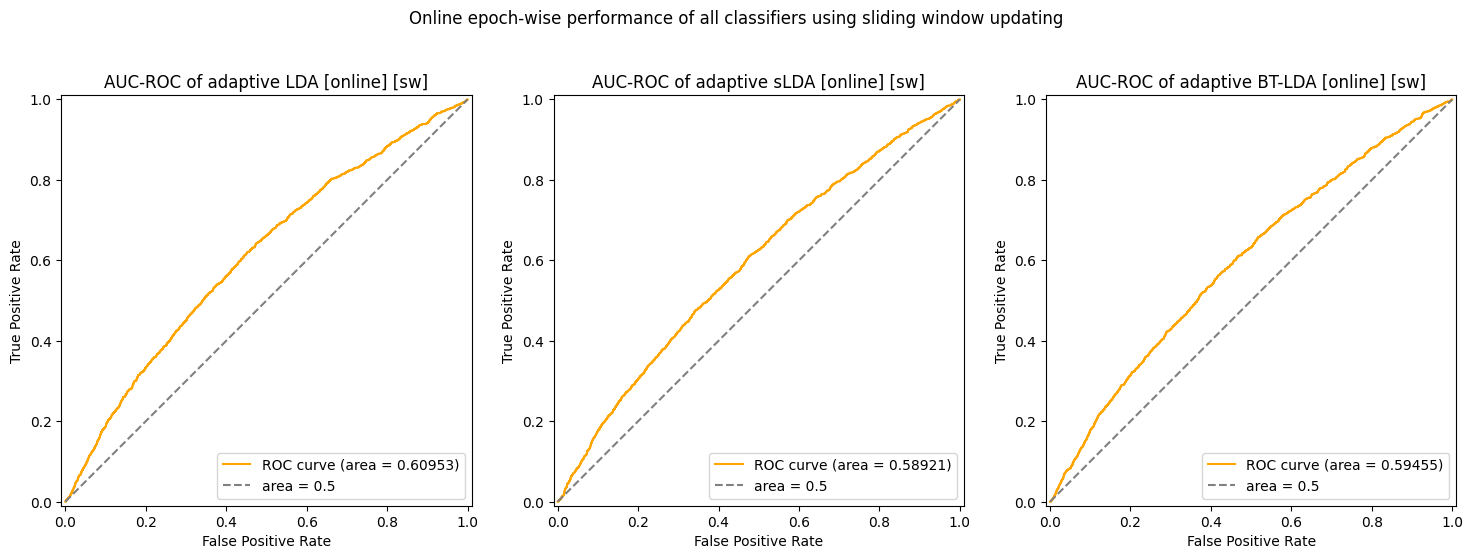

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.53175
Accuracy SLDA: 0.45238
Accuracy BT-LDA: 0.43651
Loading file:  B:_anonymized_data_P02a_P2_S10_anonymized
Corresponding .pkl file:  B:_anonymized_data_P02a_P2_S10_anonymized.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P02a_P2_S10_anonymized.pkl
Loading file:  B:_anonymized_data_P02a_P2_S11_anonymized
Corresponding .pkl file:  B:_anonymized_data_P02a_P2_S11_anonymized.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P02a_P2_S11_anonymized.pkl
AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.6092200910448567
AUC SLDA:  0.5845853500548788
AUC BT-LDA:  0.591157313277075


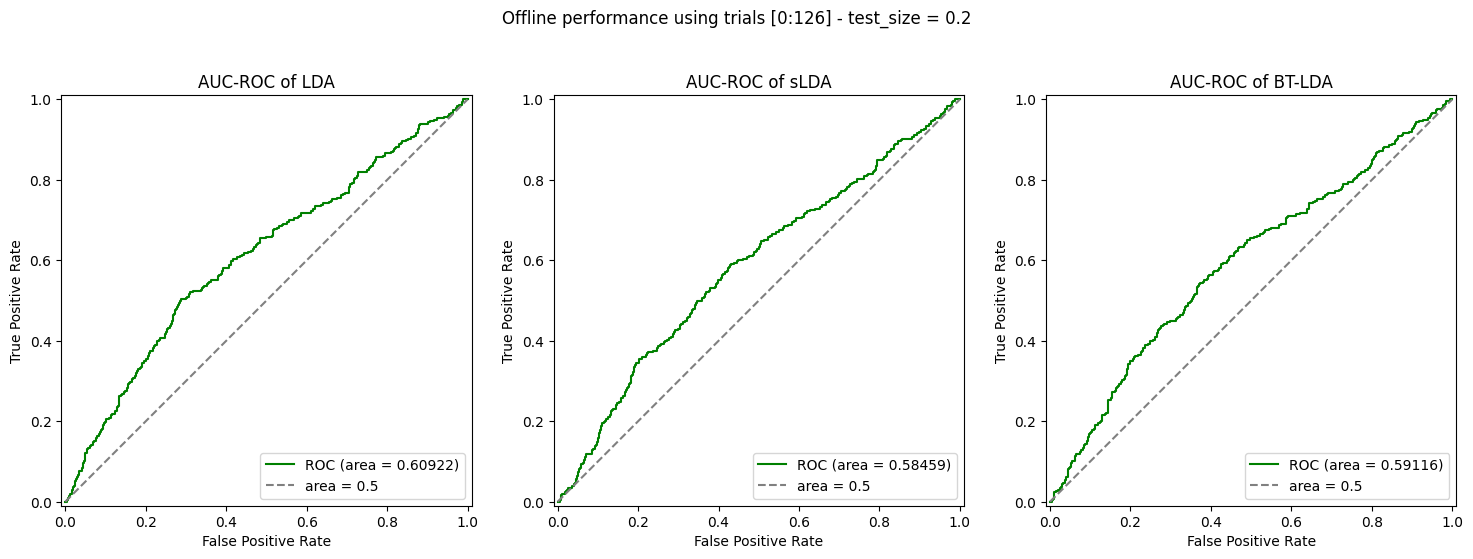

AUC scores computed using a 4-fold cross-validation
Mean AUC score of LDA: 		 0.6049881467497475
Mean AUC score of sLDA: 	 0.5867579241355729
Mean AUC score of BT-LDA: 	 0.5931704965496345
trial 0/102
trial 1/102
trial 2/102
trial 3/102
trial 4/102
trial 5/102
trial 6/102
trial 7/102
trial 8/102
trial 9/102
trial 10/102
trial 11/102
trial 12/102
trial 13/102
trial 14/102
trial 15/102
trial 16/102
trial 17/102
trial 18/102
trial 19/102
trial 20/102
trial 21/102
trial 22/102
trial 23/102
trial 24/102
trial 25/102
trial 26/102
trial 27/102
trial 28/102
trial 29/102
trial 30/102
trial 31/102
trial 32/102
trial 33/102
trial 34/102
trial 35/102
trial 36/102
trial 37/102
trial 38/102
trial 39/102
trial 40/102
trial 41/102
trial 42/102
trial 43/102
trial 44/102
trial 45/102
trial 46/102
trial 47/102
trial 48/102
trial 49/102
trial 50/102
trial 51/102
trial 52/102
trial 53/102
trial 54/102
trial 55/102
trial 56/102
trial 57/102
trial 58/102
trial 59/102
trial 60/102
trial 61/102
trial 62/102
tr

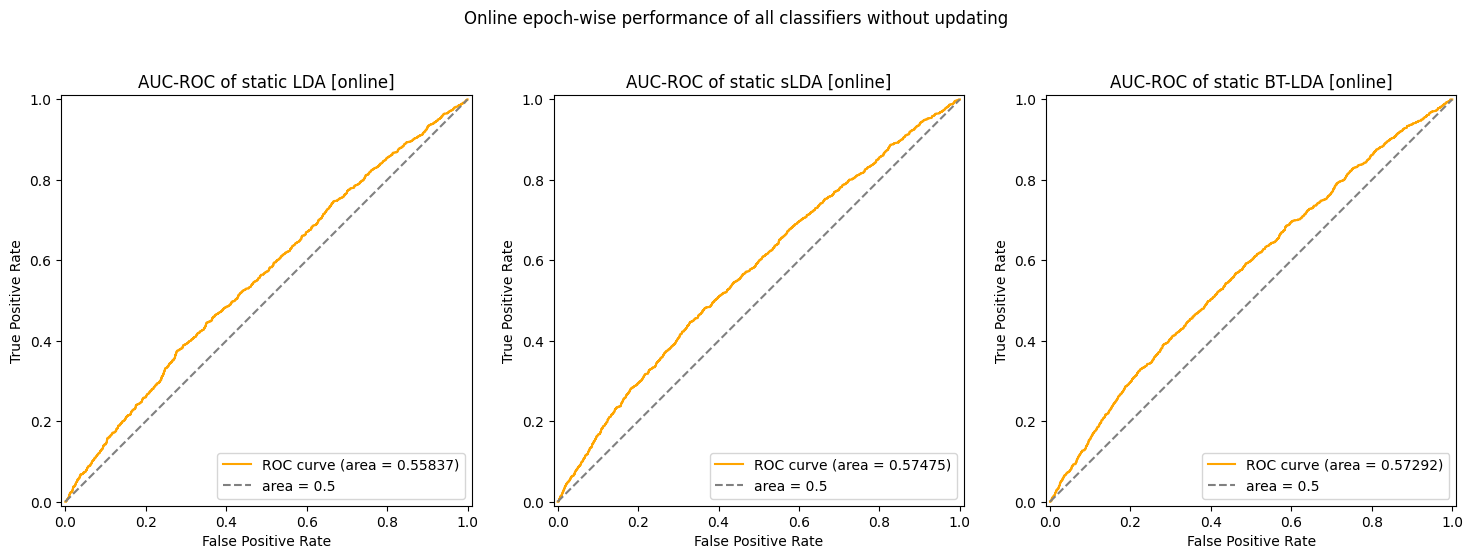

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.28431
Accuracy SLDA: 0.35294
Accuracy BT-LDA: 0.35294
trial 0/102
trial 1/102
trial 2/102
trial 3/102
trial 4/102
trial 5/102
trial 6/102
trial 7/102
trial 8/102
trial 9/102
trial 10/102
trial 11/102
trial 12/102
trial 13/102
trial 14/102
trial 15/102
trial 16/102
trial 17/102
trial 18/102
trial 19/102
trial 20/102
trial 21/102
trial 22/102
trial 23/102
trial 24/102
trial 25/102
trial 26/102
trial 27/102
trial 28/102
trial 29/102
trial 30/102
trial 31/102
trial 32/102
trial 33/102
trial 34/102
trial 35/102
trial 36/102
trial 37/102
trial 38/102
trial 39/102
trial 40/102
trial 41/102
trial 42/102
trial 43/102
trial 44/102
trial 45/102
trial 46/102
trial 47/102
trial 48/102
trial 49/102
trial 50/102
trial 51/102
trial 52/102
trial 53/102
trial 54/102
trial 55/102
trial 56/102
trial 57/102
trial 58/102
trial 59/102
trial 60/102
trial 61/102
trial 62/102
trial 63/102
trial 64/102
trial 65/102
tria

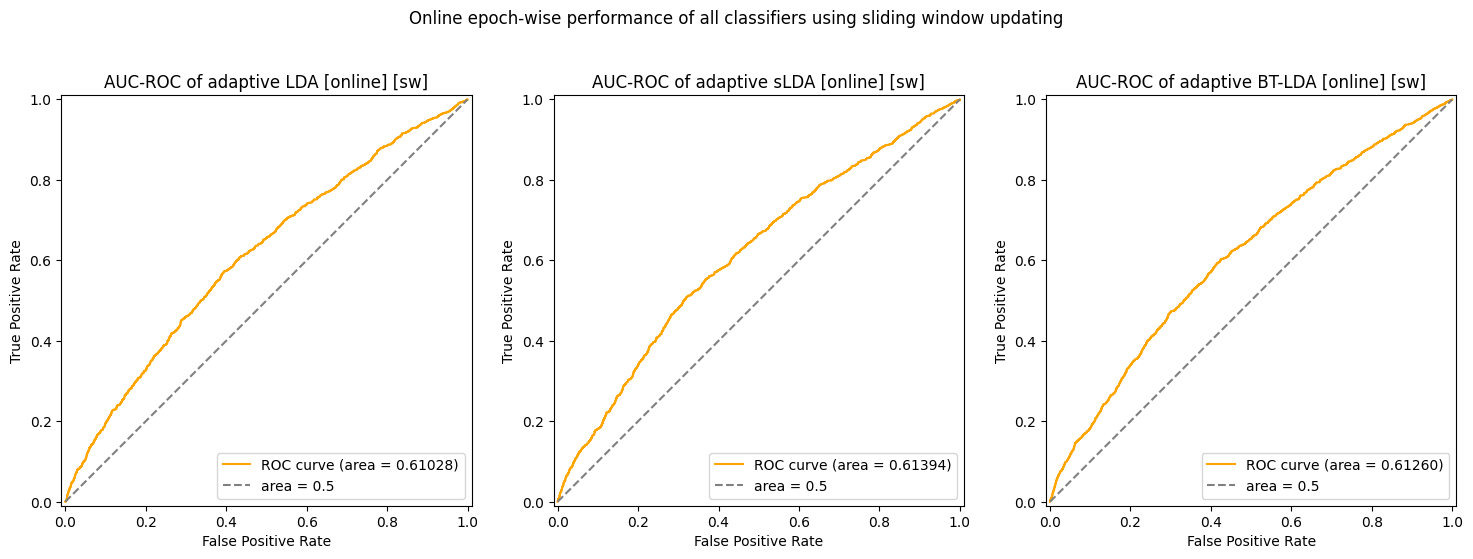

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.54902
Accuracy SLDA: 0.52941
Accuracy BT-LDA: 0.53922
Loading file:  B:_anonymized_data_P02a_P2_S11_anonymized
Corresponding .pkl file:  B:_anonymized_data_P02a_P2_S11_anonymized.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P02a_P2_S11_anonymized.pkl
Loading file:  B:_anonymized_data_P02a_P2_S12_anonymized
Corresponding .pkl file:  B:_anonymized_data_P02a_P2_S12_anonymized.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P02a_P2_S12_anonymized.pkl
AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.6210972313536416
AUC SLDA:  0.6163561984074805
AUC BT-LDA:  0.6234458324201914


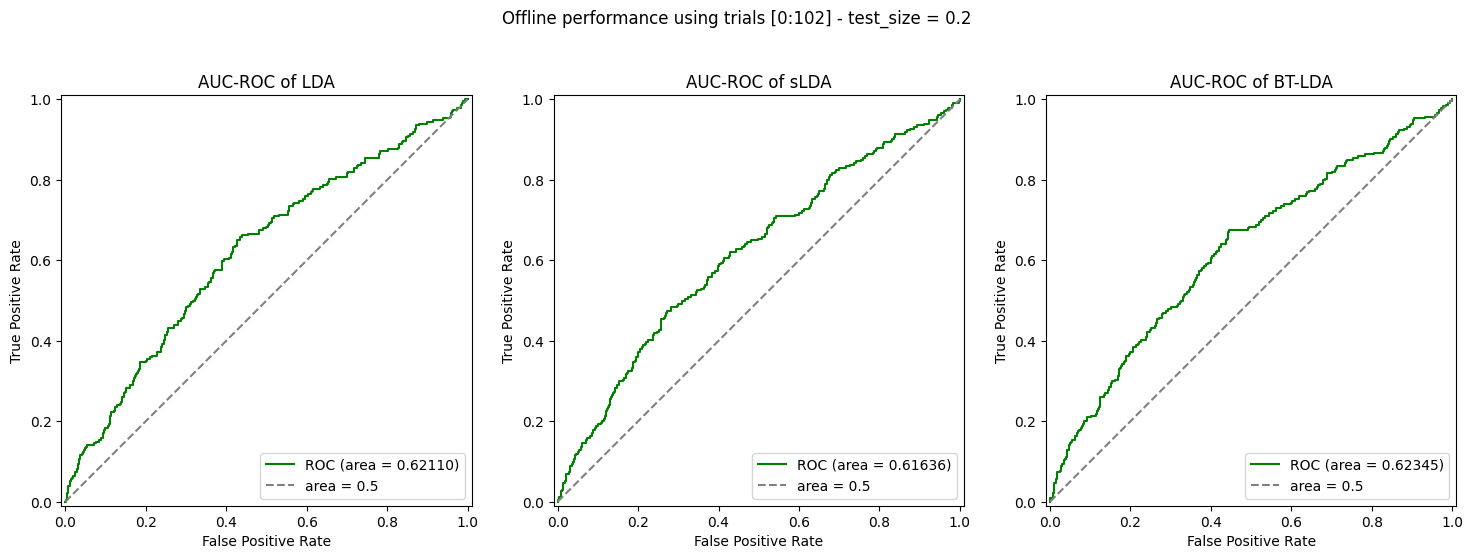

AUC scores computed using a 4-fold cross-validation
Mean AUC score of LDA: 		 0.6112632567278267
Mean AUC score of sLDA: 	 0.6065115209913383
Mean AUC score of BT-LDA: 	 0.6106902258065071
trial 0/84
trial 1/84
trial 2/84
trial 3/84
trial 4/84
trial 5/84
trial 6/84
trial 7/84
trial 8/84
trial 9/84
trial 10/84
trial 11/84
trial 12/84
trial 13/84
trial 14/84
trial 15/84
trial 16/84
trial 17/84
trial 18/84
trial 19/84
trial 20/84
trial 21/84
trial 22/84
trial 23/84
trial 24/84
trial 25/84
trial 26/84
trial 27/84
trial 28/84
trial 29/84
trial 30/84
trial 31/84
trial 32/84
trial 33/84
trial 34/84
trial 35/84
trial 36/84
trial 37/84
trial 38/84
trial 39/84
trial 40/84
trial 41/84
trial 42/84
trial 43/84
trial 44/84
trial 45/84
trial 46/84
trial 47/84
trial 48/84
trial 49/84
trial 50/84
trial 51/84
trial 52/84
trial 53/84
trial 54/84
trial 55/84
trial 56/84
trial 57/84
trial 58/84
trial 59/84
trial 60/84
trial 61/84
trial 62/84
trial 63/84
trial 64/84
trial 65/84
trial 66/84
trial 67/84
trial

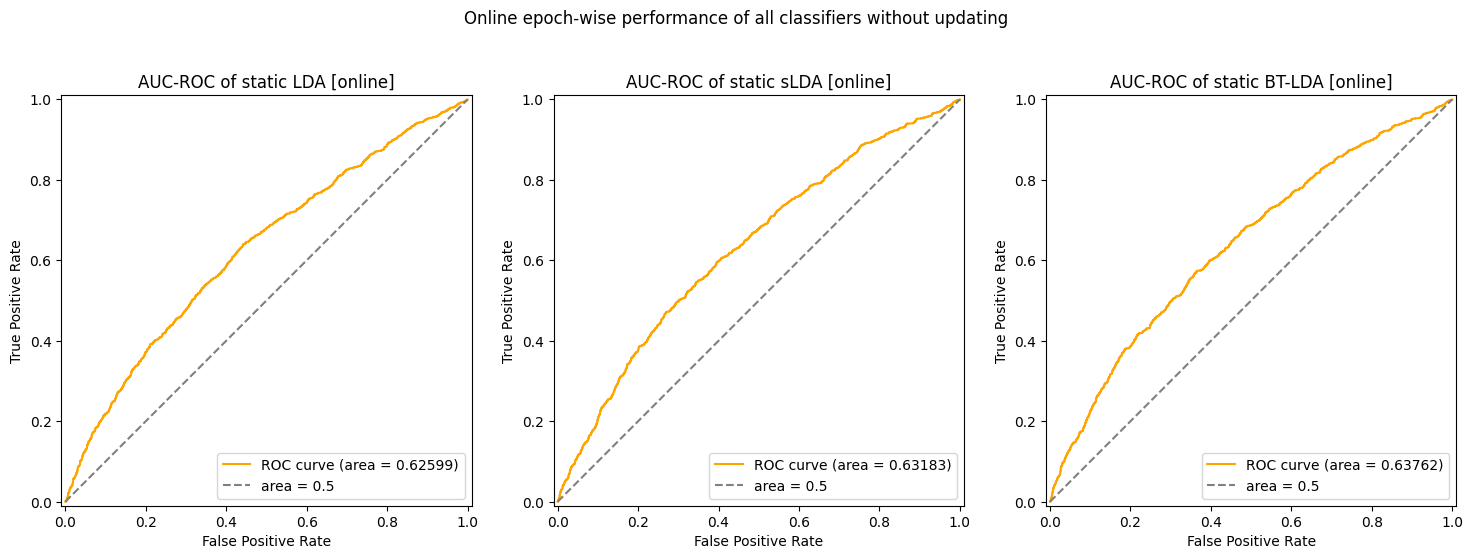

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.55952
Accuracy SLDA: 0.59524
Accuracy BT-LDA: 0.58333
trial 0/84
trial 1/84
trial 2/84
trial 3/84
trial 4/84
trial 5/84
trial 6/84
trial 7/84
trial 8/84
trial 9/84
trial 10/84
trial 11/84
trial 12/84
trial 13/84
trial 14/84
trial 15/84
trial 16/84
trial 17/84
trial 18/84
trial 19/84
trial 20/84
trial 21/84
trial 22/84
trial 23/84
trial 24/84
trial 25/84
trial 26/84
trial 27/84
trial 28/84
trial 29/84
trial 30/84
trial 31/84
trial 32/84
trial 33/84
trial 34/84
trial 35/84
trial 36/84
trial 37/84
trial 38/84
trial 39/84
trial 40/84
trial 41/84
trial 42/84
trial 43/84
trial 44/84
trial 45/84
trial 46/84
trial 47/84
trial 48/84
trial 49/84
trial 50/84
trial 51/84
trial 52/84
trial 53/84
trial 54/84
trial 55/84
trial 56/84
trial 57/84
trial 58/84
trial 59/84
trial 60/84
trial 61/84
trial 62/84
trial 63/84
trial 64/84
trial 65/84
trial 66/84
trial 67/84
trial 68/84
trial 69/84
trial 70/84
trial 71/8

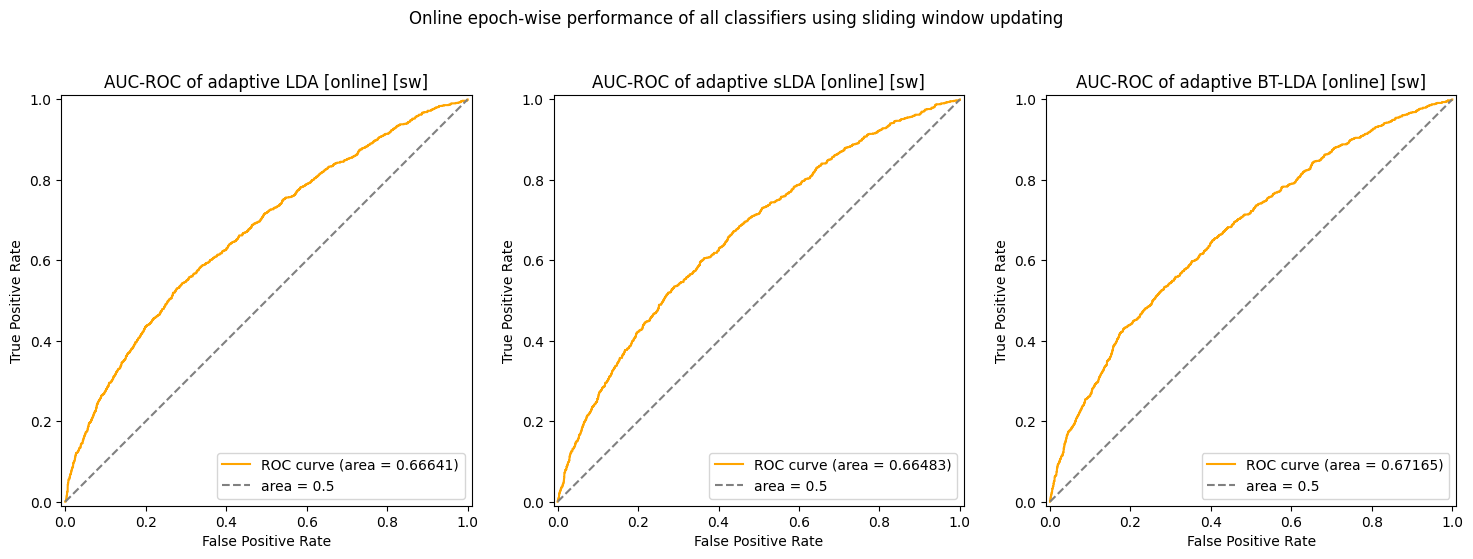

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.67857
Accuracy SLDA: 0.69048
Accuracy BT-LDA: 0.69048
Loading file:  B:_anonymized_data_P02a_P2_S12_anonymized
Corresponding .pkl file:  B:_anonymized_data_P02a_P2_S12_anonymized.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P02a_P2_S12_anonymized.pkl
Loading file:  B:_anonymized_data_P02a_P2_S13_anonymized
Corresponding .pkl file:  B:_anonymized_data_P02a_P2_S13_anonymized.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P02a_P2_S13_anonymized.pkl
AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.6623435441370223
AUC SLDA:  0.6777068040654997
AUC BT-LDA:  0.6872706098249577


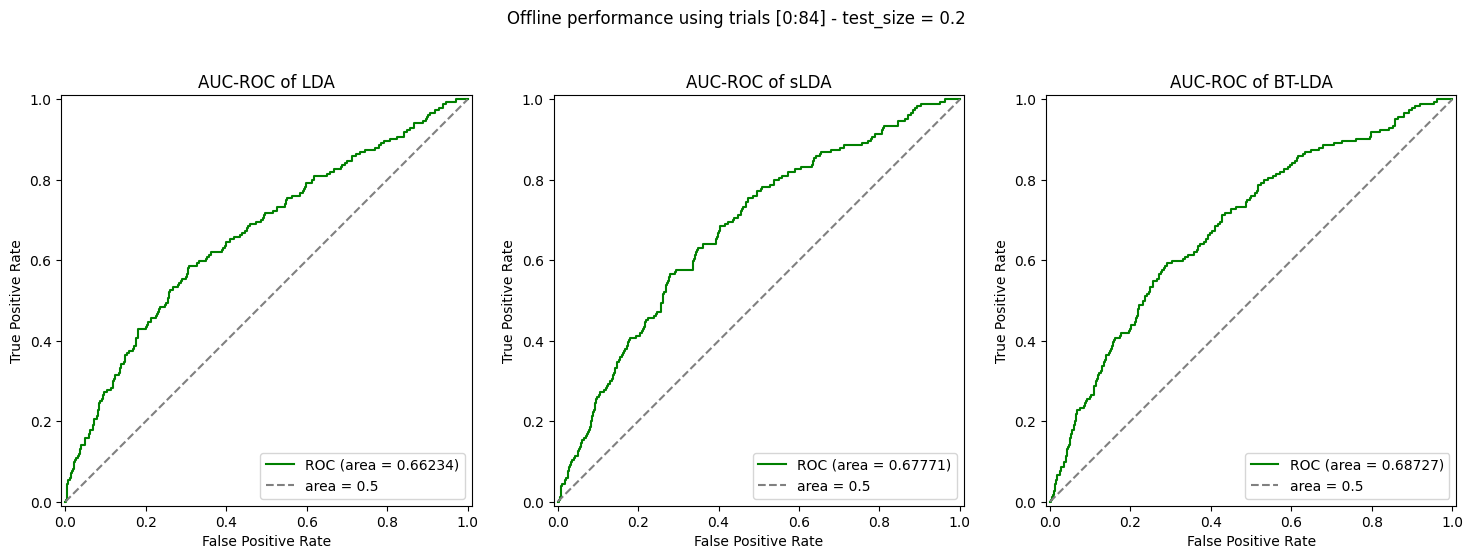

AUC scores computed using a 4-fold cross-validation
Mean AUC score of LDA: 		 0.6788502732651726
Mean AUC score of sLDA: 	 0.6761224283053183
Mean AUC score of BT-LDA: 	 0.6841641736631067
trial 0/96
trial 1/96
trial 2/96
trial 3/96
trial 4/96
trial 5/96
trial 6/96
trial 7/96
trial 8/96
trial 9/96
trial 10/96
trial 11/96
trial 12/96
trial 13/96
trial 14/96
trial 15/96
trial 16/96
trial 17/96
trial 18/96
trial 19/96
trial 20/96
trial 21/96
trial 22/96
trial 23/96
trial 24/96
trial 25/96
trial 26/96
trial 27/96
trial 28/96
trial 29/96
trial 30/96
trial 31/96
trial 32/96
trial 33/96
trial 34/96
trial 35/96
trial 36/96
trial 37/96
trial 38/96
trial 39/96
trial 40/96
trial 41/96
trial 42/96
trial 43/96
trial 44/96
trial 45/96
trial 46/96
trial 47/96
trial 48/96
trial 49/96
trial 50/96
trial 51/96
trial 52/96
trial 53/96
trial 54/96
trial 55/96
trial 56/96
trial 57/96
trial 58/96
trial 59/96
trial 60/96
trial 61/96
trial 62/96
trial 63/96
trial 64/96
trial 65/96
trial 66/96
trial 67/96
trial

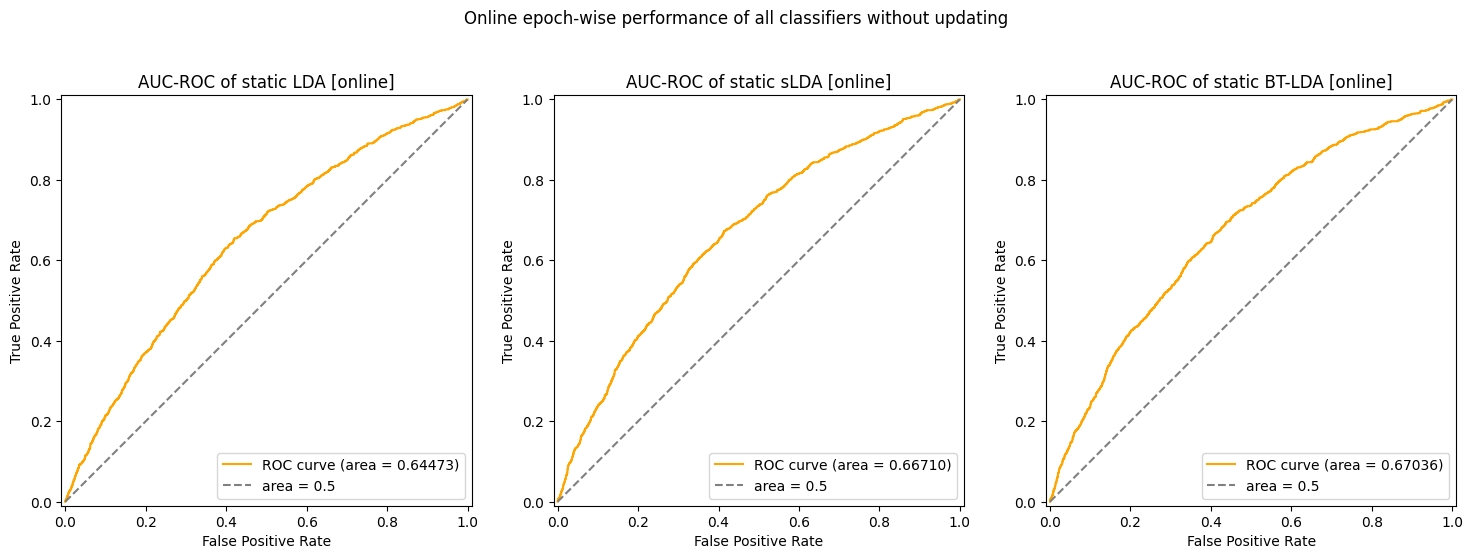

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.66667
Accuracy SLDA: 0.72917
Accuracy BT-LDA: 0.75000
trial 0/96
trial 1/96
trial 2/96
trial 3/96
trial 4/96
trial 5/96
trial 6/96
trial 7/96
trial 8/96
trial 9/96
trial 10/96
trial 11/96
trial 12/96
trial 13/96
trial 14/96
trial 15/96
trial 16/96
trial 17/96
trial 18/96
trial 19/96
trial 20/96
trial 21/96
trial 22/96
trial 23/96
trial 24/96
trial 25/96
trial 26/96
trial 27/96
trial 28/96
trial 29/96
trial 30/96
trial 31/96
trial 32/96
trial 33/96
trial 34/96
trial 35/96
trial 36/96
trial 37/96
trial 38/96
trial 39/96
trial 40/96
trial 41/96
trial 42/96
trial 43/96
trial 44/96
trial 45/96
trial 46/96
trial 47/96
trial 48/96
trial 49/96
trial 50/96
trial 51/96
trial 52/96
trial 53/96
trial 54/96
trial 55/96
trial 56/96
trial 57/96
trial 58/96
trial 59/96
trial 60/96
trial 61/96
trial 62/96
trial 63/96
trial 64/96
trial 65/96
trial 66/96
trial 67/96
trial 68/96
trial 69/96
trial 70/96
trial 71/9

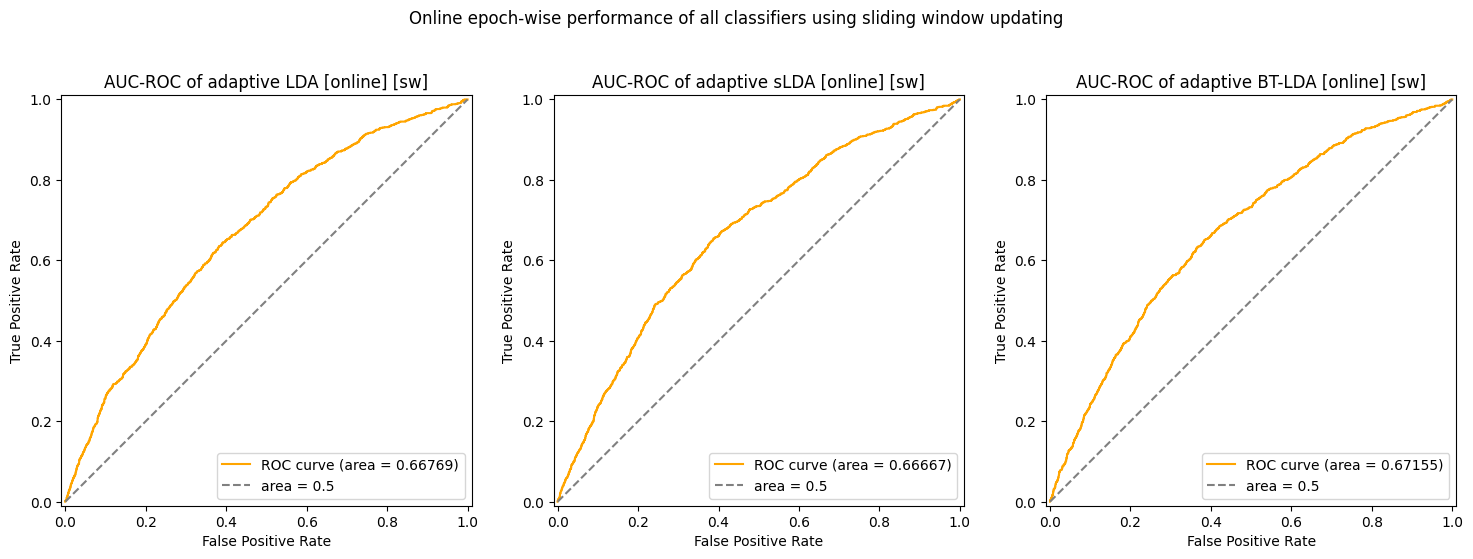

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.77083
Accuracy SLDA: 0.73958
Accuracy BT-LDA: 0.75000


In [19]:

p2_performances_s4_to_s13 = dict()
for i in range(4,14):
    # 1. Only load the runs of session s-1 as training data
    
    data_train = load_session_chached(f"B:/anonymized_data/P02a/P2_S{i-1}/anonymized")
    trials_train = data_train.get("trials")

    data_test = load_session_chached(f"B:/anonymized_data/P02a/P2_S{i}/anonymized")
    trials_test = data_test.get("trials")

    ppcal = data_train.get('preprocessing')
    fncal = data_train.get('filenames')
    ppon = data_test.get('preprocessing')
    fnon = data_test.get('filenames')

    # 2. Evaluate offline performance 
    clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
    compare_auc_single_trial_interval(trials_train, start=0, stop=None, test_size=0.2, only_auc = True, ival_bounds = clf_ival_boundaries, plot_roc_curves=True)
    compute_auc_with_cv(trials_train, start=0, stop=None, ival_bounds=clf_ival_boundaries, cv_folds=4, show_mean=True, show_folds=False)

    # 3. Online simulation static (trained on session i-1 - applied on session i)
    static_result = online_simulation(trials_train, trials_test, log_process=f"p2_s{i}_online_static.log", preprocessing_calibration=ppcal, preprocessing_online=ppon, filenames_calibration=fncal, filenames_online=fnon)

    # 4. Online simulation with sliding window adaptation (trained on session i-1 - applied on session i)
    adaptive_sw_result = online_adaptation_simulation_sw(trials_train, trials_test, log_process=f"p2_s{i}_online_adaptive_sw.log", preprocessing_calibration=ppcal, preprocessing_online=ppon, filenames_calibration=fncal, filenames_online=fnon)

    p2_performances_s4_to_s13.update({f"p2_s{i}_static":static_result})
    p2_performances_s4_to_s13.update({f"p2_s{i}_adaptive_sw":adaptive_sw_result})